# AI Modeling for Healthcare Accessibility (Casablanca)

## Objective
This notebook adds a machine learning layer **after** the accessibility pipeline. The accessibility model remains the core method; ML is used to:

1. predict accessibility patterns at origin level,
2. identify determinants of poor access,
3. support scenario interpretation for policy.

In [62]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

ROOT = Path(r"D:\\Capstone\\capstone_repo")
DATA_INTERIM = ROOT / "data" / "interim"
DATA_FINAL = ROOT / "data" / "final"
MODELING_RESULTS = ROOT / DATA_FINAL / "modeling_results"
FIG_DIR = ROOT / "outputs" / "figures"
MODELING_RESULTS.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ACCESS_THRESHOLD = 50
TEST_SIZE = 0.2

print("ROOT:", ROOT)

ROOT: D:\Capstone\capstone_repo


## Data loading and preparation

We load origin-level and district-level outputs from the accessibility pipeline and create a modeling table with fallback logic for column names.

In [22]:
def pick_existing_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Missing required file. Checked: {candidates}")

def first_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in cols:
            return cols[c.lower()]
    return None

origin_path = pick_existing_path([
    DATA_INTERIM / "origin_accessibility_metrics.csv",
    DATA_INTERIM / "worldpop_origins.csv",
])
district_path = pick_existing_path([DATA_FINAL / "district_accessibility_summary.csv"])

origins_raw = pd.read_csv(origin_path)
districts_raw = pd.read_csv(district_path)

print("Origins path:", origin_path)
print("District path:", district_path)
print("Origins shape:", origins_raw.shape)
print("Districts shape:", districts_raw.shape)

Origins path: D:\Capstone\capstone_repo\data\interim\origin_accessibility_metrics.csv
District path: D:\Capstone\capstone_repo\data\final\district_accessibility_summary.csv
Origins shape: (70273, 28)
Districts shape: (34, 10)


# Build Modeling Table for Predictive Analysis

In [23]:
# Compute great-circle distance in kilometers between two geographic coordinates
def haversine_km(lon1, lat1, lon2, lat2):
    # Convert longitude values from degrees to radians
    lon1 = np.radians(lon1)
    lon2 = np.radians(lon2)

    # Convert latitude values from degrees to radians
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    # Compute coordinate differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Apply the Haversine formula
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2

    # Return distance in kilometers
    return 6371.0 * (2 * np.arcsin(np.sqrt(np.clip(a, 0, 1))))


# Build a clean modeling table from origin-level and district-level data
def build_model_df(origins_df, districts_df):
    # Create a copy to avoid modifying the original input
    df = origins_df.copy()

    # Detect the district ID column from possible alternatives
    district_id_col = first_col(df, ["district_id", "district", "district_code"])

    # Detect the district name column from possible alternatives
    district_name_col = first_col(df, ["district_name", "district", "commune"])

    # Rename detected district ID column to a standard name if needed
    if district_id_col and district_id_col != "district_id":
        df = df.rename(columns={district_id_col: "district_id"})

    # Create a fallback district ID if none exists
    if "district_id" not in df.columns:
        df["district_id"] = "unknown"

    # Rename detected district name column to a standard name if needed
    if district_name_col and district_name_col != "district_name":
        df = df.rename(columns={district_name_col: "district_name"})

    # Convert selected feature columns to numeric where available
    for c in [
        "population", "x", "y", "walk_dist_to_stop_m", "walk_time_to_stop_min",
        "num_facilities_reachable_30min", "num_facilities_reachable_60min",
        "accessibility_score", "score_2sfca", "total_travel_time_min"
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Replace infinite values from unreachable travel paths with NaN so imputers can handle them
    finite_cleanup_cols = [
        c for c in [
            "population", "x", "y", "walk_dist_to_stop_m", "walk_time_to_stop_min",
            "num_facilities_reachable_30min", "num_facilities_reachable_60min",
            "accessibility_score", "score_2sfca", "total_travel_time_min"
        ] if c in df.columns
    ]
    if finite_cleanup_cols:
        df[finite_cleanup_cols] = df[finite_cleanup_cols].replace([np.inf, -np.inf], np.nan)

    # Clean population values and create a log-transformed population feature
    if "population" in df.columns:
        df["population"] = df["population"].clip(lower=0)
        df["log_population"] = np.log1p(df["population"])

    # Create spatial features if projected or geographic coordinates are available
    if {"x", "y"}.issubset(df.columns):
        # Use median coordinates as the reference center
        lon0 = df["x"].median(skipna=True)
        lat0 = df["y"].median(skipna=True)

        # Compute distance from each origin to the dataset center
        df["dist_to_center_km"] = haversine_km(df["x"], df["y"], lon0, lat0)

        # Define peripheral origins as those above the 75th percentile in center distance
        q75 = df["dist_to_center_km"].quantile(0.75)
        df["is_periphery"] = (df["dist_to_center_km"] >= q75).astype(int)

    # Select safe district-level contextual features only
    keep_d = ["district_id"]
    keep_d = [c for c in keep_d if c in districts_df.columns]

    # Merge district-level context into the origin-level table
    if keep_d:
        dctx = districts_df[keep_d].drop_duplicates(subset=["district_id"])
        df = df.merge(dctx, on="district_id", how="left")

    # Ensure the target-driving accessibility score is present
    if "accessibility_score" not in df.columns:
        raise KeyError("accessibility_score is required")

    # Convert accessibility score to numeric
    df["accessibility_score"] = pd.to_numeric(df["accessibility_score"], errors="coerce")

    # Remove rows with missing accessibility score
    df = df[df["accessibility_score"].notna()].copy()

    # Create binary target: 1 if underserved, 0 otherwise
    df["y_under"] = (df["accessibility_score"] < ACCESS_THRESHOLD).astype(int)

    # Return the final modeling table
    return df


# Build the final modeling dataset
model_df = build_model_df(origins_raw, districts_raw)

# Print basic dataset shape and share of underserved origins
print("Model table shape:", model_df.shape)
print("Underserved share:", round(model_df["y_under"].mean(), 4))

Model table shape: (70273, 32)
Underserved share: 0.6663


## Threshold rationale and sensitivity

`ACCESS_THRESHOLD = 50` is kept as the operational baseline for classifying underserved origins. To test robustness, we also report underserved shares under nearby thresholds (40 and 60).

In [24]:
threshold_candidates = [40, 50, 60]
threshold_sensitivity = pd.DataFrame({
    "threshold": threshold_candidates,
    "underserved_share": [
        (pd.to_numeric(model_df["accessibility_score"], errors="coerce") < t).mean()
        for t in threshold_candidates
    ],
})

display(threshold_sensitivity)

,threshold,underserved_share
0,40,0.554936
1,50,0.666301
2,60,0.797091


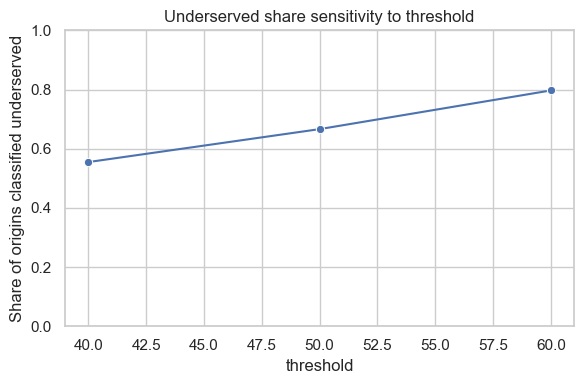

In [25]:
# Visualize how the share of underserved origins changes with different thresholds
plt.figure(figsize=(6, 4))
sns.lineplot(data=threshold_sensitivity, x="threshold", y="underserved_share", marker="o")
plt.ylim(0, 1)
plt.title("Underserved share sensitivity to threshold")
plt.ylabel("Share of origins classified underserved")
plt.tight_layout()
plt.show()

## Leakage feature detection and exclusion

In [26]:
model_df["y_access"] = pd.to_numeric(model_df["accessibility_score"], errors="coerce")
model_df["y_2sfca"] = pd.to_numeric(model_df["score_2sfca"], errors="coerce")

In [27]:
LEAKAGE_EXCLUDE = {
    "accessibility_score",
    "total_travel_time_min",
    "num_facilities_reachable_30min",
    "num_facilities_reachable_60min",
    "score_2sfca",
    "y_under",
    "is_access_30",
    "is_unreachable",
    "nearest_facility_id",
    "chosen_stop_key",
}

removed_leakage_cols = [c for c in model_df.columns if c in LEAKAGE_EXCLUDE]
print("Removed leakage columns:")
for c in removed_leakage_cols:
    print(" -", c)

Removed leakage columns:
 - chosen_stop_key
 - nearest_facility_id
 - total_travel_time_min
 - accessibility_score
 - num_facilities_reachable_30min
 - num_facilities_reachable_60min
 - is_unreachable
 - score_2sfca
 - y_under


## Clean feature sets

- `clean_conservative`: fundamental predictors only.
- `clean_enriched`: conservative + safe transformations/interactions (still leakage-free).

In [28]:
# Safe interaction features
if {"walk_time_to_stop_min", "dist_to_center_km"}.issubset(model_df.columns):
    model_df["walk_time_x_center"] = model_df["walk_time_to_stop_min"] * model_df["dist_to_center_km"]
if {"walk_dist_to_stop_m", "population"}.issubset(model_df.columns):
    model_df["walk_dist_x_pop"] = model_df["walk_dist_to_stop_m"] * np.log1p(model_df["population"])

clean_conservative = [
    "population",
    "walk_time_to_stop_min",
    "walk_dist_to_stop_m",
    "x",
    "y",
    "dist_to_center_km",
    "is_periphery",
]

clean_enriched = clean_conservative + [
    "log_population",
    "walk_time_x_center",
    "walk_dist_x_pop",
]

def keep_valid(cols):
    out = []
    for c in cols:
        if c in model_df.columns and c not in LEAKAGE_EXCLUDE:
            out.append(c)
    return out

feature_sets_clean = {
    "clean_conservative": keep_valid(clean_conservative),
    "clean_enriched": keep_valid(clean_enriched),
}

for k, v in feature_sets_clean.items():
    if len(v) == 0:
        raise ValueError(f"Feature set {k} is empty")
    print(f"{k} ({len(v)} features): {v}")

clean_conservative (7 features): ['population', 'walk_time_to_stop_min', 'walk_dist_to_stop_m', 'x', 'y', 'dist_to_center_km', 'is_periphery']
clean_enriched (10 features): ['population', 'walk_time_to_stop_min', 'walk_dist_to_stop_m', 'x', 'y', 'dist_to_center_km', 'is_periphery', 'log_population', 'walk_time_x_center', 'walk_dist_x_pop']


## EDA

These diagnostics help validate model reliability: missingness reveals data quality risk, univariate distributions show skew/outliers and class separation signal, and spatial scatter checks whether underserved origins cluster geographically.

In [29]:
# Missingness by modeling features
modeling_features = sorted({f for fs in feature_sets_clean.values() for f in fs if f in model_df.columns})
missingness_df = (
    model_df[modeling_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_rate_pct")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(missingness_df)

,feature,missing_rate_pct
0,dist_to_center_km,0.0
1,is_periphery,0.0
2,log_population,0.0
3,population,0.0
4,walk_dist_to_stop_m,0.0
5,walk_dist_x_pop,0.0
6,walk_time_to_stop_min,0.0
7,walk_time_x_center,0.0
8,x,0.0
9,y,0.0


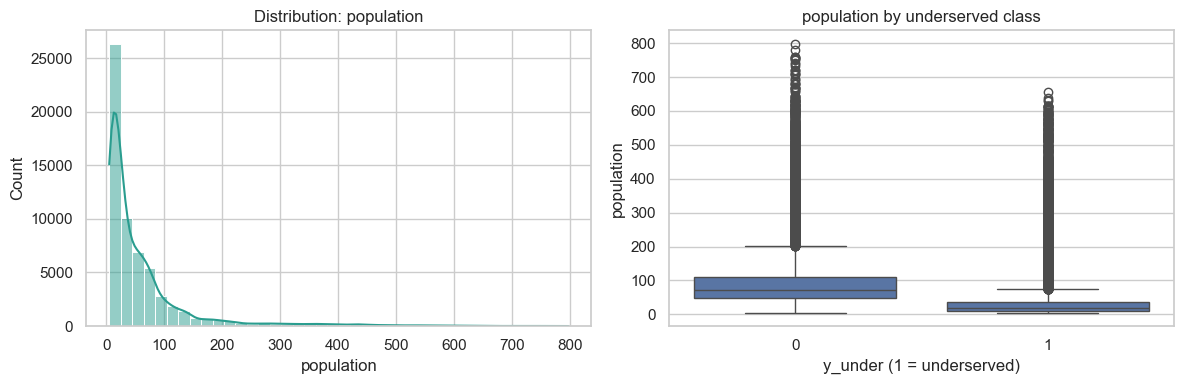

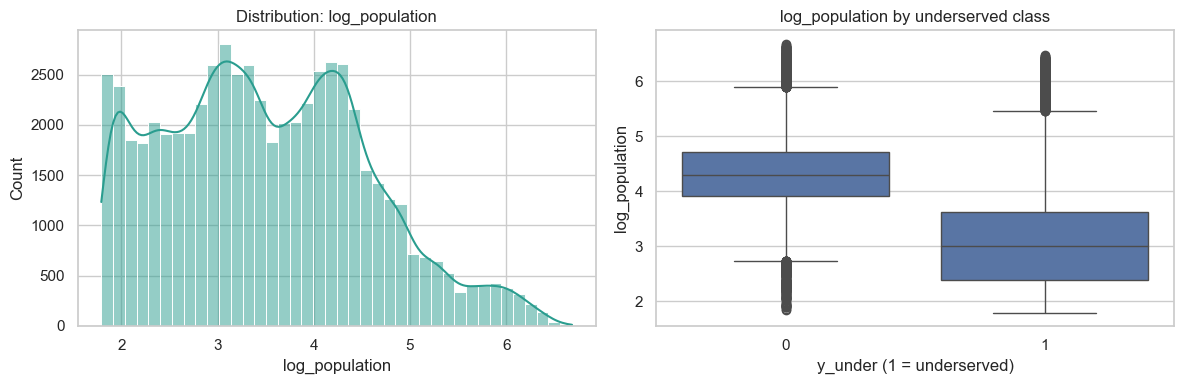

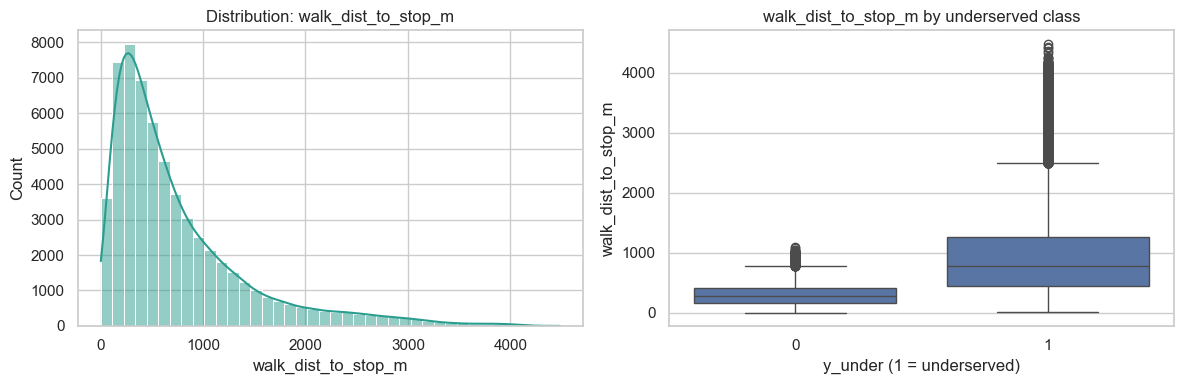

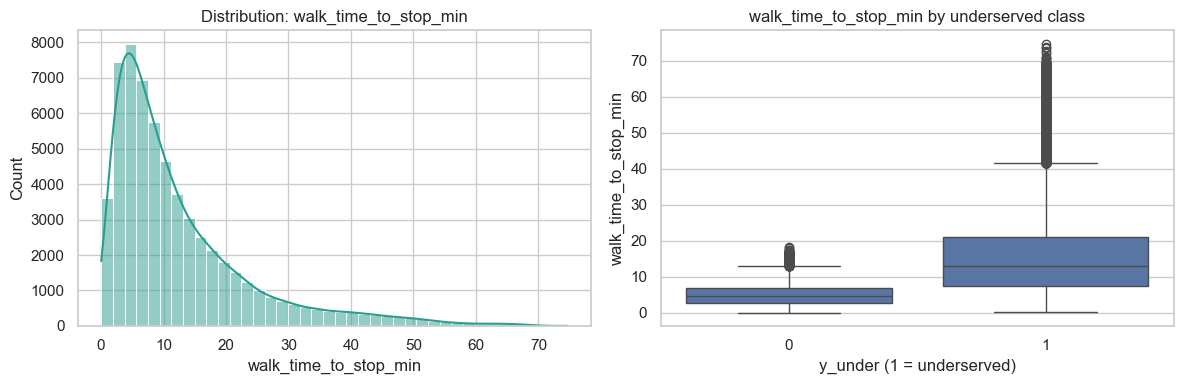

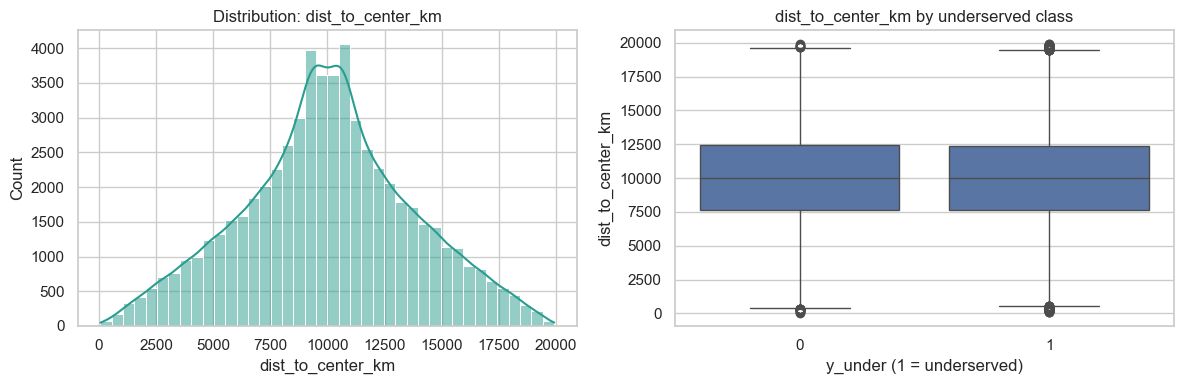

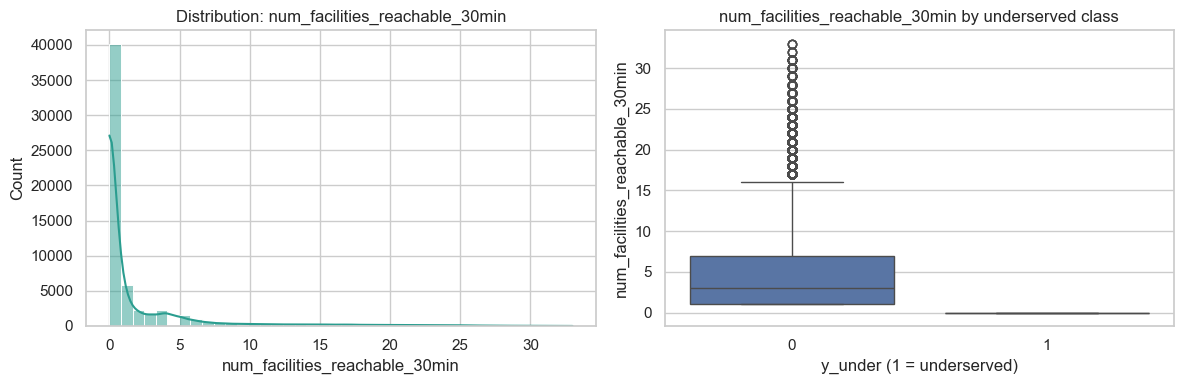

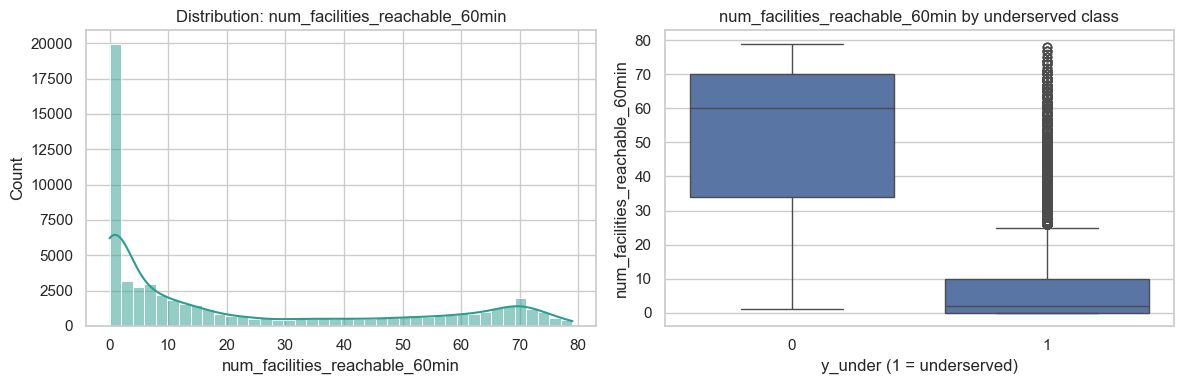

In [30]:
# Univariate diagnostics for key predictors (availability-guarded)
key_predictors = [
    "population",
    "log_population",
    "walk_dist_to_stop_m",
    "walk_time_to_stop_min",
    "dist_to_center_km",
    "num_facilities_reachable_30min",
    "num_facilities_reachable_60min",
]
available_predictors = [c for c in key_predictors if c in model_df.columns]

if available_predictors:
    for col in available_predictors:
        tmp = model_df[[col, "y_under"]].copy()
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
        tmp = tmp.dropna(subset=[col, "y_under"])
        if tmp.empty:
            continue
        if len(tmp) > 60000:
            tmp = tmp.sample(60000, random_state=RANDOM_STATE)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(tmp[col], bins=40, kde=True, ax=axes[0], color="#2A9D8F")
        axes[0].set_title(f"Distribution: {col}")

        sns.boxplot(data=tmp, x="y_under", y=col, ax=axes[1])
        axes[1].set_title(f"{col} by underserved class")
        axes[1].set_xlabel("y_under (1 = underserved)")

        plt.tight_layout()
        plt.show()
else:
    print("No key predictors available for univariate diagnostics.")



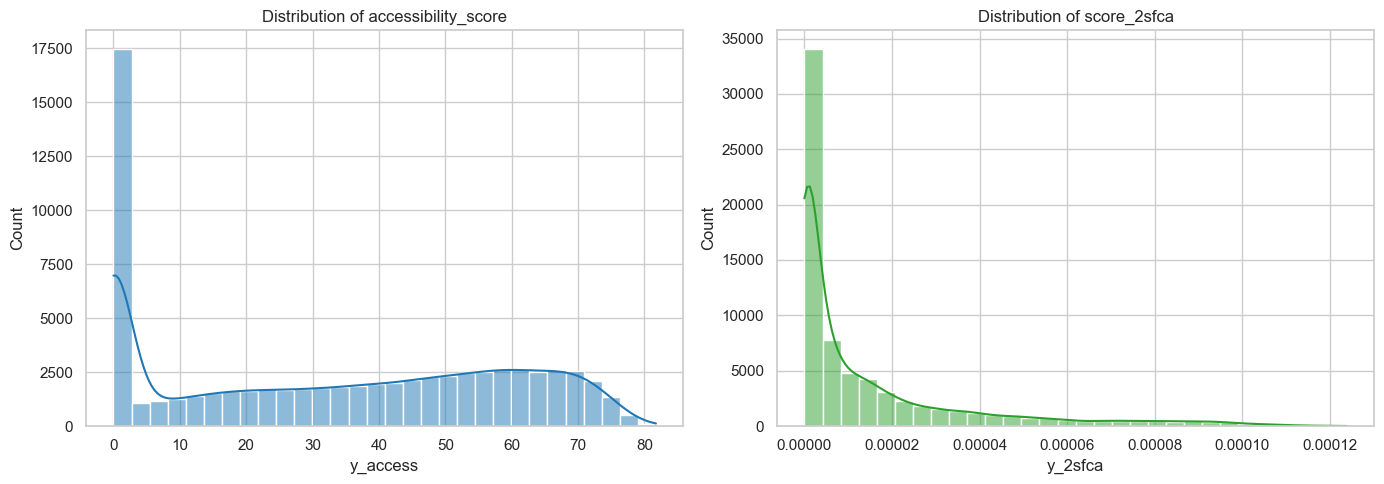

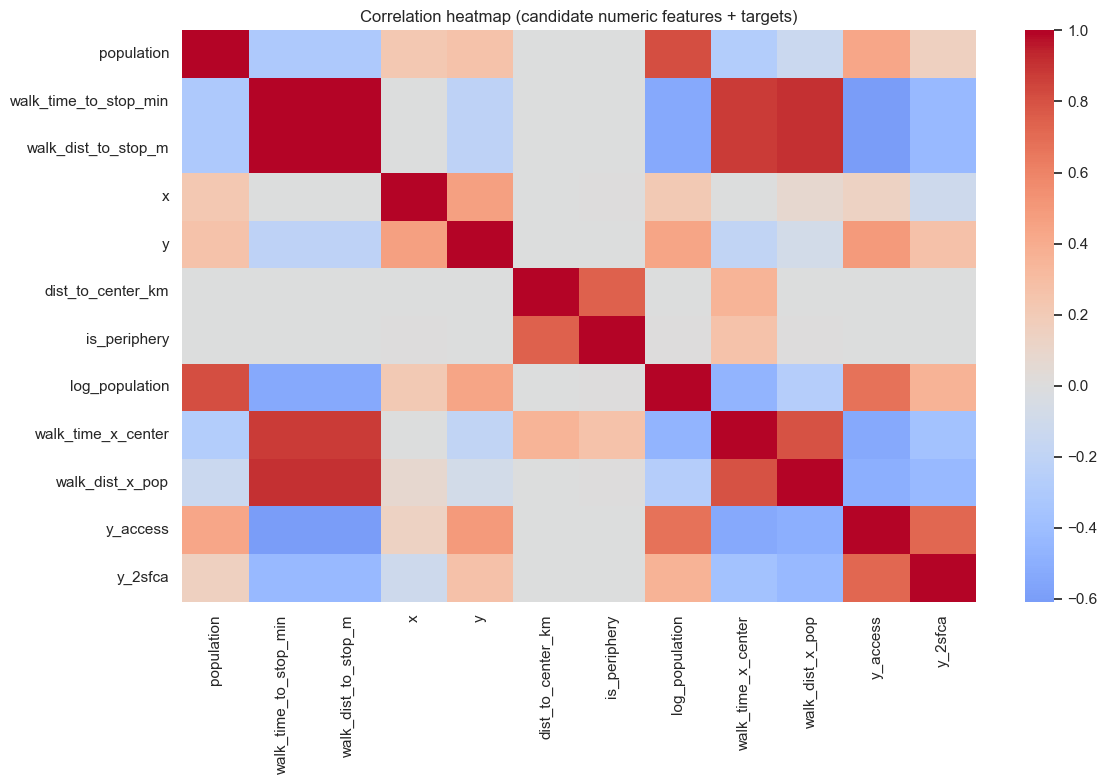

,count
y_under,
Underserved,46823
Not underserved,23450


Underserved percentage: 66.63 %


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(model_df["y_access"], bins=30, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribution of accessibility_score")
sns.histplot(model_df["y_2sfca"], bins=30, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Distribution of score_2sfca")
plt.tight_layout()
plt.savefig(FIG_DIR / "ai_targets_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

num_cols = [c for c in feature_sets_clean["clean_enriched"] if pd.api.types.is_numeric_dtype(model_df[c])]
corr_cols = list(dict.fromkeys(num_cols + ["y_access", "y_2sfca"]))
if len(corr_cols) >= 3:
    plt.figure(figsize=(12, 8))
    corr = model_df[corr_cols].corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation heatmap (candidate numeric features + targets)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ai_feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()

class_counts = model_df["y_under"].value_counts(dropna=False).rename(index={0: "Not underserved", 1: "Underserved"})
display(class_counts.to_frame("count"))
print("Underserved percentage:", (100 * model_df["y_under"].mean()).round(2), "%")

# Regression pipeline

Utility functions used to prepare feature matrix and train regression models:
- Numerical features: imputed using median and standardized, when required by the model.
- Categorical features: imputed using the most frequent value and one-hot encoded

Models Used:
- Linear Regression
- Random Forest
- Gradient Boosting                    

Evaluated using **cross-validation** on training set and final evaluation on a held-out test set.

Evaluation Metrics include:
- RMSE
- MSE
- R^2

In [32]:
# Split features into numeric and categorical columns
def split_feature_types(X):
    # Keep columns with numeric data types
    numeric_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]

    # Treat all remaining columns as categorical
    categorical_features = [c for c in X.columns if c not in numeric_features]

    # Return both feature lists
    return numeric_features, categorical_features

In [33]:
# Build a preprocessing pipeline for numeric and categorical features
def make_preprocessor(X, scale_numeric=False):
    # Identify numeric and categorical columns
    num_cols, cat_cols = split_feature_types(X)

    # Create preprocessing steps for numeric features
    num_steps = [("imputer", SimpleImputer(strategy="median"))]

    # Optionally standardize numeric features
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    # Combine numeric steps into a pipeline
    num_pipe = Pipeline(num_steps)

    # Create preprocessing pipeline for categorical features
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    # Combine numeric and categorical pipelines
    pre = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop")

    # Return the complete preprocessor
    return pre

In [34]:
# Compute common regression performance metrics
def regression_metrics(y_true, y_pred):
    # Return RMSE, MAE, and R² in dictionary format
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


# Train and evaluate multiple regression models on the same dataset
def train_regression_suite(X, y, feature_set_name, target_name):
    # Import training and evaluation tools locally
    from sklearn.model_selection import train_test_split, KFold, cross_validate
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np
    import pandas as pd

    # Split data into training and test subsets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Define cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Define the set of regression models to compare
    specs = [
        ("LinearRegression", LinearRegression(), True),
        ("RandomForest", RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=1
        ), False),
        ("GradientBoosting", GradientBoostingRegressor(random_state=42), False),
    ]

    # Initialize outputs for CV results, test results, and fitted models
    cv_rows, test_rows, fitted_models = [], [], {}

    # Loop through each model specification
    for name, model, scale in specs:
        # Create full pipeline: preprocessing + model
        pipe = Pipeline([
            ("preprocessor", make_preprocessor(X_train, scale_numeric=scale)),
            ("model", model),
        ])

        # Evaluate model with cross-validation on training data
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "rmse": "neg_root_mean_squared_error",
                "mae": "neg_mean_absolute_error",
                "r2": "r2"
            },
            n_jobs=1,
            error_score="raise"
        )

        # Store average cross-validation metrics
        cv_rows.append({
            "task": target_name,
            "feature_set": feature_set_name,
            "model": name,
            "CV_RMSE": -scores["test_rmse"].mean(),
            "CV_MAE": -scores["test_mae"].mean(),
            "CV_R2": scores["test_r2"].mean(),
        })

        # Fit the model on the full training set
        pipe.fit(X_train, y_train)

        # Generate predictions on the held-out test set
        y_pred = pipe.predict(X_test)

        # Store final test-set metrics
        test_rows.append({
            "task": target_name,
            "feature_set": feature_set_name,
            "model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred),
        })

        # Save fitted model and prediction artifacts for later analysis
        fitted_models[name] = (pipe, X_test.copy(), y_test.copy(), y_pred.copy())

    # Return CV metrics, test metrics, and fitted objects
    return pd.DataFrame(cv_rows), pd.DataFrame(test_rows), fitted_models

## 1. PREDICT Accessibility_Score

In [35]:
reg_cv_all, reg_test_all, reg_fits_store = [], [], {}

# Loop through each predefined feature set
for fs_name, fs_cols in feature_sets_clean.items():
    # Skip empty feature sets
    if not fs_cols:
        continue

    # Extract predictors for the current feature set
    X = model_df[fs_cols].copy()

    # Extract regression target variable
    y = model_df["y_access"].copy()

    # Train and evaluate regression models for this feature set
    cv_df, test_df, fitted = train_regression_suite(X, y, fs_name, "accessibility_score")

    # Store cross-validation results
    reg_cv_all.append(cv_df)

    # Store test-set results
    reg_test_all.append(test_df)

    # Store fitted models and related artifacts for later inspection
    reg_fits_store[("accessibility_score", fs_name)] = fitted

# Combine all cross-validation results into one table
reg_cv_access = pd.concat(reg_cv_all, ignore_index=True)

# Combine all test results into one table
reg_test_access = pd.concat(reg_test_all, ignore_index=True)

# Display cross-validation results sorted by best RMSE and MAE
print("Cross-validation results (sorted by RMSE and MAE):")
display(reg_cv_access.sort_values(["CV_RMSE", "CV_MAE"]))

# Display test results sorted by best RMSE and MAE
print("Test results (sorted by RMSE and MAE):")
display(reg_test_access.sort_values(["RMSE", "MAE"]))

Cross-validation results (sorted by RMSE and MAE):


,task,feature_set,model,CV_RMSE,CV_MAE,CV_R2
1,accessibility_score,clean_conservative,RandomForest,3.610604,2.328728,0.980387
4,accessibility_score,clean_enriched,RandomForest,3.630176,2.344486,0.980175
2,accessibility_score,clean_conservative,GradientBoosting,7.283961,5.513620,0.920192
5,accessibility_score,clean_enriched,GradientBoosting,7.309100,5.518196,0.919635
3,accessibility_score,clean_enriched,LinearRegression,15.307824,11.754409,0.647567
0,accessibility_score,clean_conservative,LinearRegression,17.427999,14.281945,0.543202


Test results (sorted by RMSE and MAE):


,task,feature_set,model,RMSE,MAE,R2
1,accessibility_score,clean_conservative,RandomForest,3.637798,2.334265,0.980256
4,accessibility_score,clean_enriched,RandomForest,3.654896,2.347251,0.980070
5,accessibility_score,clean_enriched,GradientBoosting,7.244261,5.429804,0.921702
2,accessibility_score,clean_conservative,GradientBoosting,7.404525,5.588483,0.918199
3,accessibility_score,clean_enriched,LinearRegression,15.410509,11.849960,0.645677
0,accessibility_score,clean_conservative,LinearRegression,17.474833,14.359304,0.544392


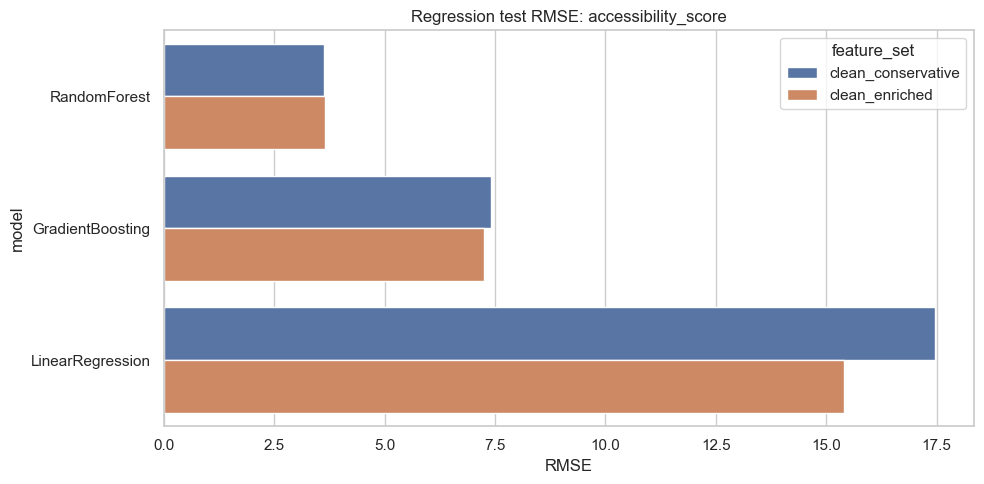

In [36]:
# Visualize regression test RMSE for different models and feature sets
plt.figure(figsize=(10, 5))

# Sort results by RMSE for clearer plotting
plot_df = reg_test_access.sort_values("RMSE")

# Plot bar chart of regression test RMSE
sns.barplot(data=plot_df, x="RMSE", y="model", hue="feature_set")
plt.title("Regression test RMSE: accessibility_score")
plt.tight_layout()

# Save figure for report
plt.savefig(FIG_DIR / "ai_regression_access_rmse.png", dpi=160, bbox_inches="tight")

plt.show()

## 2. PREDICT: 2SFCA

In [37]:
reg2_cv_all, reg2_test_all, reg2_fits_store = [], [], {}

# Loop through each feature set
for fs_name, fs_cols in feature_sets_clean.items():
    # Skip empty feature sets
    if not fs_cols:
        continue

    # Extract features for current feature set
    X = model_df[fs_cols].copy()

    # Extract target variable (2SFCA score)
    y = model_df["y_2sfca"].copy()

    # Train regression models and evaluate performance
    cv_df, test_df, fitted = train_regression_suite(X, y, fs_name, "score_2sfca")

    # Store cross-validation results
    reg2_cv_all.append(cv_df)

    # Store test-set results
    reg2_test_all.append(test_df)

    # Store fitted models for later analysis
    reg2_fits_store[("score_2sfca", fs_name)] = fitted

# Concatenate all cross-validation results into one DataFrame
reg_cv_2sfca = pd.concat(reg2_cv_all, ignore_index=True)

# Concatenate all test results into one DataFrame
reg_test_2sfca = pd.concat(reg2_test_all, ignore_index=True)

# Display cross-validation results sorted by best performance
print("Cross-validation results (sorted by RMSE and MAE):")
display(reg_cv_2sfca.sort_values(["CV_RMSE", "CV_MAE"]))

# Display test results sorted by best performance
print("Test results (sorted by RMSE and MAE):")
display(reg_test_2sfca.sort_values(["RMSE", "MAE"]))

Cross-validation results (sorted by RMSE and MAE):


,task,feature_set,model,CV_RMSE,CV_MAE,CV_R2
1,score_2sfca,clean_conservative,RandomForest,0.000003,0.000001,0.984567
4,score_2sfca,clean_enriched,RandomForest,0.000003,0.000001,0.984395
5,score_2sfca,clean_enriched,GradientBoosting,0.000005,0.000003,0.945643
2,score_2sfca,clean_conservative,GradientBoosting,0.000005,0.000003,0.945286
3,score_2sfca,clean_enriched,LinearRegression,0.000018,0.000012,0.383521
0,score_2sfca,clean_conservative,LinearRegression,0.000019,0.000014,0.265755


Test results (sorted by RMSE and MAE):


,task,feature_set,model,RMSE,MAE,R2
1,score_2sfca,clean_conservative,RandomForest,0.000003,0.000001,0.984206
4,score_2sfca,clean_enriched,RandomForest,0.000003,0.000001,0.984104
5,score_2sfca,clean_enriched,GradientBoosting,0.000005,0.000003,0.948012
2,score_2sfca,clean_conservative,GradientBoosting,0.000005,0.000003,0.947180
3,score_2sfca,clean_enriched,LinearRegression,0.000018,0.000012,0.384144
0,score_2sfca,clean_conservative,LinearRegression,0.000020,0.000014,0.267008


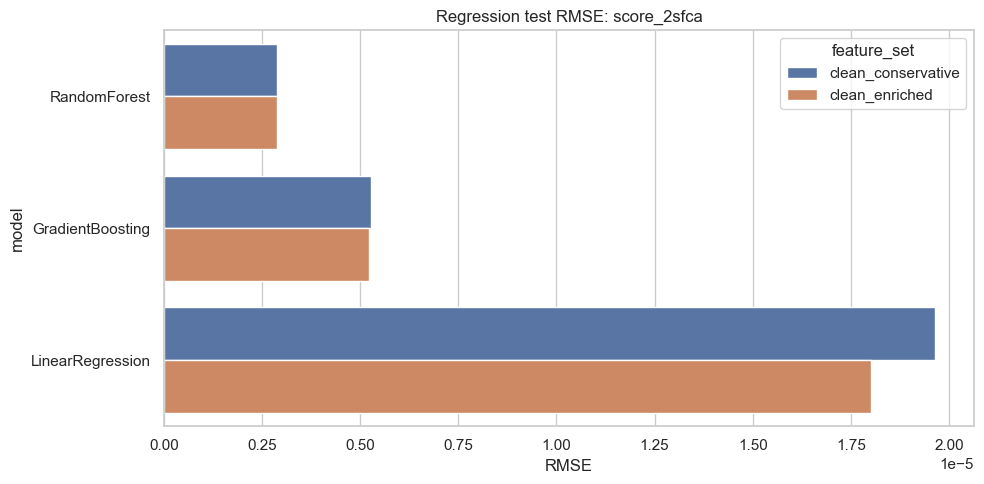

In [38]:
plt.figure(figsize=(10, 5))

# Sort models by RMSE
plot_df = reg_test_2sfca.sort_values("RMSE")

# Plot RMSE values for each model and feature set
sns.barplot(data=plot_df, x="RMSE", y="model", hue="feature_set")

plt.title("Regression test RMSE: score_2sfca")
plt.tight_layout()
plt.savefig(FIG_DIR / "ai_regression_2sfca_rmse.png", dpi=160, bbox_inches="tight")

plt.show()

# Classification pipeline

Settings requested:
- `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- scoring with accuracy/precision/recall/f1/roc_auc
- `n_jobs=1` in cross-validation and Random Forest

This section defines helper functions for classification experiments.

First, a utility function computes standard classification metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC. Then, a training function is defined to build and evaluate several classifiers under a consistent preprocessing pipeline.

The function splits the data into training and test sets using stratified sampling, applies cross-validation on the training data, and evaluates final performance on the held-out test set. It also supports an optional balanced mode through class weights to handle class imbalance.


In [39]:
# Compute common classification performance metrics
def compute_cls_metrics(y_true, y_pred, y_prob):
    # Return standard classification metrics in dictionary form
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
    }


# Train and evaluate multiple classification models on a clean pipeline
def train_classification_clean(X, y, feature_set_name, balanced=False):
    # Split data into train and test sets using stratified sampling
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    # Define stratified cross-validation strategy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # Set class weighting option
    class_weight = "balanced" if balanced else None

    # Store balancing mode label for results
    balance_tag = "balanced" if balanced else "unbalanced"

    # Define candidate classification models
    models = [
        (
            "LogisticRegression",
            LogisticRegression(
                max_iter=2000,
                class_weight=class_weight,
                random_state=RANDOM_STATE
            ),
            True
        ),
        (
            "RandomForest",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=12,
                min_samples_leaf=5,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            False,
        ),
        (
            "GradientBoosting",
            GradientBoostingClassifier(random_state=RANDOM_STATE),
            False
        ),
    ]

    # Define evaluation metrics for cross-validation
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }

    # Initialize result containers
    cv_rows, test_rows, fitted = [], [], {}

    # Loop through each model
    for model_name, model, needs_scale in models:
        # Build preprocessing + model pipeline
        pipe = Pipeline([
            ("preprocessor", make_preprocessor(X_train, scale_numeric=needs_scale)),
            ("model", model),
        ])

        # Evaluate model using cross-validation on training data
        scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

        # Store mean cross-validation metrics
        cv_rows.append({
            "feature_set": feature_set_name,
            "balance_mode": balance_tag,
            "model": model_name,
            "CV_Accuracy": scores["test_accuracy"].mean(),
            "CV_Precision": scores["test_precision"].mean(),
            "CV_Recall": scores["test_recall"].mean(),
            "CV_F1": scores["test_f1"].mean(),
            "CV_ROC_AUC": scores["test_roc_auc"].mean(),
        })

        # Fit pipeline on full training data
        pipe.fit(X_train, y_train)

        # Predict class labels on the test set
        y_pred = pipe.predict(X_test)

        # Predict positive-class probabilities when supported
        y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else np.zeros(len(y_test))

        # Compute final test-set metrics
        test_m = compute_cls_metrics(y_test, y_pred, y_prob)

        # Store test-set metrics
        test_rows.append({
            "feature_set": feature_set_name,
            "balance_mode": balance_tag,
            "model": model_name,
            **test_m,
        })

        # Save fitted model and prediction artifacts for later inspection
        fitted[(feature_set_name, balance_tag, model_name)] = (
            pipe,
            X_test.copy(),
            y_test.copy(),
            y_pred,
            y_prob
        )

    # Return cross-validation results, test results, and fitted models
    return pd.DataFrame(cv_rows), pd.DataFrame(test_rows), fitted

## Train and evaluate

We produce:
- `cls_cv_clean`
- `cls_test_clean`

In [59]:
y = model_df["y_under"].astype(int).copy()

cv_frames, test_frames = [], []
fitted_store = {}

for fs_name, cols in feature_sets_clean.items():
    X = model_df[cols].copy()
    cv_df, test_df, fitted = train_classification_clean(X, y, fs_name, balanced=False)
    cv_frames.append(cv_df)
    test_frames.append(test_df)
    fitted_store.update(fitted)

cls_cv_clean = pd.concat(cv_frames, ignore_index=True)
cls_test_clean = pd.concat(test_frames, ignore_index=True)

print("Cross-validation results (sorted by F1 and ROC AUC):")
display(cls_cv_clean.sort_values(["CV_F1", "CV_ROC_AUC"], ascending=False))
print("Test results (sorted by F1 and ROC AUC):")
display(cls_test_clean.sort_values(["F1", "ROC_AUC"], ascending=False))


Cross-validation results (sorted by F1 and ROC AUC):


,feature_set,balance_mode,model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC
1,clean_conservative,unbalanced,RandomForest,0.966541,0.979359,0.970233,0.974773,0.994621
4,clean_enriched,unbalanced,RandomForest,0.965100,0.976125,0.971381,0.973746,0.994467
2,clean_conservative,unbalanced,GradientBoosting,0.942421,0.959530,0.953815,0.956659,0.986261
5,clean_enriched,unbalanced,GradientBoosting,0.942154,0.959762,0.953147,0.956437,0.986466
3,clean_enriched,unbalanced,LogisticRegression,0.858906,0.908667,0.876368,0.892215,0.930370
0,clean_conservative,unbalanced,LogisticRegression,0.833025,0.882947,0.863981,0.873345,0.905246


Test results (sorted by F1 and ROC AUC):


,feature_set,balance_mode,model,Accuracy,Precision,Recall,F1,ROC_AUC
4,clean_enriched,unbalanced,RandomForest,0.967983,0.979869,0.971917,0.975876,0.995419
1,clean_conservative,unbalanced,RandomForest,0.967414,0.980369,0.970529,0.975424,0.995353
5,clean_enriched,unbalanced,GradientBoosting,0.942156,0.959390,0.953550,0.956461,0.986631
2,clean_conservative,unbalanced,GradientBoosting,0.940662,0.957623,0.953123,0.955368,0.985938
3,clean_enriched,unbalanced,LogisticRegression,0.857702,0.908577,0.874426,0.891174,0.928821
0,clean_conservative,unbalanced,LogisticRegression,0.831448,0.880383,0.864495,0.872367,0.902821


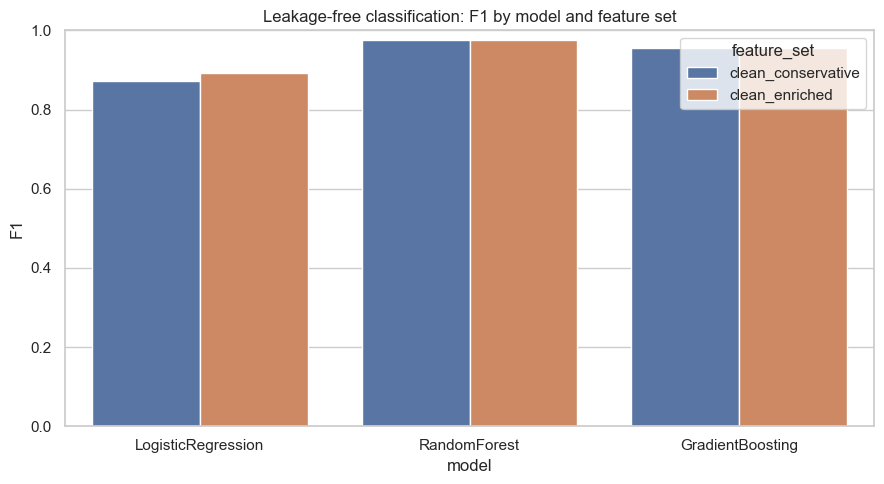

In [56]:
# 1) Bar plot of F1 by model and feature set
plt.figure(figsize=(9, 5))
sns.barplot(data=cls_test_clean, x="model", y="F1", hue="feature_set")
plt.title("Leakage-free classification: F1 by model and feature set")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_clean_f1_barplot.png", dpi=160, bbox_inches="tight")
plt.show()

# Best model from clean results
best_row = cls_test_clean.sort_values(["F1", "ROC_AUC"], ascending=False).iloc[0]
best_key = (best_row["feature_set"], best_row["balance_mode"], best_row["model"])
best_pipe, X_test_best, y_test_best, y_pred_best, y_prob_best = fitted_store[best_key]

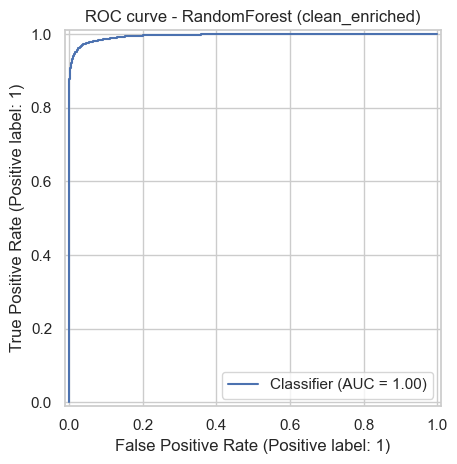

In [57]:
# 2) ROC curve
RocCurveDisplay.from_predictions(y_test_best, y_prob_best)
plt.title(f"ROC curve - {best_row['model']} ({best_row['feature_set']})")
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_clean_best_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

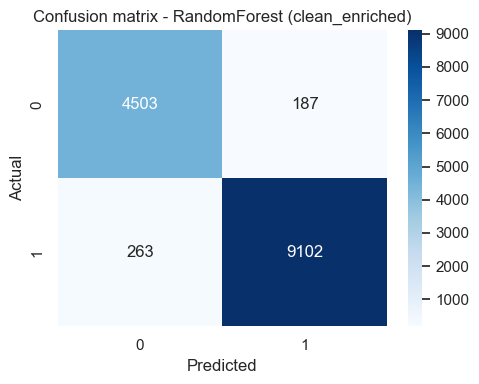

In [58]:
# 3) Confusion matrix
cm = confusion_matrix(y_test_best, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion matrix - {best_row['model']} ({best_row['feature_set']})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_clean_best_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## Primary evaluation: grouped district holdout

Random splits can be spatially optimistic because nearby origins may share similar conditions. We therefore use grouped district holdout as the primary generalization test for out-of-district performance.

This section is the main generalization evaluation and tests how well the best classification model transfers across districts.

First, the best-performing clean setup is selected. Then, a grouped holdout strategy is applied: one district at a time is used as the test set, while all other districts are used for training. This is the primary test because the model is evaluated on districts it has not seen during training.

For each eligible district, the model is retrained, predictions are generated, and F1-score and ROC-AUC are computed. Random-split performance is kept as a secondary comparison table.

In [69]:
# Create a classification model object from its name and balancing choice
def make_classification_model(model_name, balanced=False):
    # Use class weighting only when balanced mode is requested
    class_weight = "balanced" if balanced else None

    # Return Logistic Regression and indicate that scaling is needed
    if model_name == "LogisticRegression":
        return (
            LogisticRegression(
                max_iter=2000,
                class_weight=class_weight,
                random_state=RANDOM_STATE
            ),
            True
        )

    # Return Random Forest and indicate that scaling is not needed
    if model_name == "RandomForest":
        return (
            RandomForestClassifier(
                n_estimators=250,
                max_depth=12,
                min_samples_leaf=5,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            False,
        )

    # Return Gradient Boosting and indicate that scaling is not needed
    if model_name == "GradientBoosting":
        return GradientBoostingClassifier(random_state=RANDOM_STATE), False

    # Raise an error for unsupported model names
    raise ValueError(f"Unsupported model name: {model_name}")

In [70]:
# Run grouped district holdout as the primary generalization evaluation
if "district_id" in model_df.columns:
    # Use random-split results only as secondary comparison baseline
    cls_test_clean_sorted = cls_test_clean.sort_values(["F1", "ROC_AUC"], ascending=False).reset_index(drop=True)
    ref_row = cls_test_clean_sorted.iloc[0]

    # Extract the best feature set, model, and balancing mode
    ref_feature_set = ref_row["feature_set"]
    ref_model_name = ref_row["model"]
    ref_balanced = str(ref_row.get("balance_mode", "unbalanced")) == "balanced"

    # Standardize district IDs and count observations per district
    district_series = model_df["district_id"].fillna("unknown").astype(str)
    district_counts = district_series.value_counts()

    # Keep the largest districts for holdout evaluation
    holdout_districts = (
        district_counts.head(30).index.tolist()
        if len(district_counts) > 30
        else district_counts.index.tolist()
    )

    # Extract predictors from the best feature set
    X_all = model_df[feature_sets_clean[ref_feature_set]].copy()

    # Extract binary target variable
    y_all = model_df["y_under"].astype(int).copy()

    # Initialize container for district-level evaluation results
    rows = []

    # Loop through each candidate holdout district
    for d in holdout_districts:
        # Define train/test masks for grouped district holdout
        test_mask = district_series == d
        train_mask = district_series != d

        # Count train and test samples
        n_test = int(test_mask.sum())
        n_train = int(train_mask.sum())

        # Skip very small folds to avoid unstable evaluation
        if n_test < 50 or n_train < 500:
            continue

        # Split predictors and targets into district holdout train/test sets
        X_train, X_test = X_all.loc[train_mask].copy(), X_all.loc[test_mask].copy()
        y_train, y_test = y_all.loc[train_mask].copy(), y_all.loc[test_mask].copy()

        try:
            # Recreate the best model configuration
            model, needs_scale = make_classification_model(
                ref_model_name,
                balanced=ref_balanced
            )

            # Build preprocessing + model pipeline
            pipe = Pipeline([
                ("preprocessor", make_preprocessor(X_train, scale_numeric=needs_scale)),
                ("model", model),
            ])

            # Fit the model on all districts except the holdout district
            pipe.fit(X_train, y_train)

            # Predict labels for the holdout district
            y_pred = pipe.predict(X_test)

            # Predict positive-class probabilities when supported
            if hasattr(pipe, "predict_proba"):
                y_prob = pipe.predict_proba(X_test)[:, 1]
            else:
                y_prob = np.zeros(len(y_test))

            # Compute F1-score on the holdout district
            f1_val = f1_score(y_test, y_pred, zero_division=0)

            # Compute ROC-AUC only when both classes are present
            roc_val = roc_auc_score(y_test, y_prob) if y_test.nunique() > 1 else np.nan

            # Store district-level evaluation results
            rows.append({
                "district_id": d,
                "n_test": n_test,
                "underserved_rate_test": float(y_test.mean()),
                "F1": f1_val,
                "ROC_AUC": roc_val,
            })

        except Exception as ex:
            # Store failure details if the district evaluation crashes
            rows.append({
                "district_id": d,
                "n_test": n_test,
                "underserved_rate_test": float(y_test.mean()) if len(y_test) else np.nan,
                "F1": np.nan,
                "ROC_AUC": np.nan,
                "error": str(ex)[:120],
            })

    # Convert collected rows into a DataFrame
    grouped_district_eval = pd.DataFrame(rows)

    # Handle the case where no valid district folds were produced
    if grouped_district_eval.empty:
        print("Grouped district holdout produced no valid folds (likely due to fold-size constraints).")

    else:
        # Sort district results by best holdout performance
        grouped_district_eval = grouped_district_eval.sort_values(
            ["F1", "ROC_AUC"],
            ascending=False
        )

        # Display per-district holdout results
        display(grouped_district_eval)

        # Build a compact summary: primary grouped holdout vs secondary random split
        grouped_summary = pd.DataFrame([
            {
                "evaluation": "Grouped district holdout mean",
                "F1": grouped_district_eval["F1"].mean(skipna=True),
                "ROC_AUC": grouped_district_eval["ROC_AUC"].mean(skipna=True),
            },
            {
                "evaluation": "Secondary comparison: random split best clean",
                "F1": ref_row["F1"],
                "ROC_AUC": ref_row["ROC_AUC"],
            },
        ])

        # Display primary grouped-holdout summary and secondary random-split table
        display(grouped_summary)
        display(cls_test_clean_sorted)

# Skip grouped evaluation if district IDs are unavailable
else:
    print("district_id not available in model_df; skipped grouped district holdout evaluation.")

,district_id,n_test,underserved_rate_test,F1,ROC_AUC
6,2,3016,1.000000,1.000000,NaN
13,23,1513,1.000000,1.000000,NaN
27,19,381,1.000000,1.000000,NaN
1,0,7607,0.996451,0.996967,0.828262
23,24,641,1.000000,0.977671,NaN
29,25,304,0.779605,0.962801,0.998300
0,1,14086,0.900895,0.952573,0.898076
18,33,1194,0.964824,0.952123,0.949673
25,22,503,0.091451,0.931818,0.994292
2,32,6304,0.898794,0.923878,0.894222


,evaluation,F1,ROC_AUC
0,Grouped district holdout mean,0.674851,0.873856
1,Secondary comparison: random split best clean,0.975876,0.995419


,feature_set,balance_mode,model,Accuracy,Precision,Recall,F1,ROC_AUC
0,clean_enriched,unbalanced,RandomForest,0.967983,0.979869,0.971917,0.975876,0.995419
1,clean_conservative,unbalanced,RandomForest,0.967414,0.980369,0.970529,0.975424,0.995353
2,clean_enriched,unbalanced,GradientBoosting,0.942156,0.959390,0.953550,0.956461,0.986631
3,clean_conservative,unbalanced,GradientBoosting,0.940662,0.957623,0.953123,0.955368,0.985938
4,clean_enriched,unbalanced,LogisticRegression,0.857702,0.908577,0.874426,0.891174,0.928821
5,clean_conservative,unbalanced,LogisticRegression,0.831448,0.880383,0.864495,0.872367,0.902821


## Feature importance (best model)
We use permutation importance to identify strongest predictors under a leakage-free setup.

In [46]:
# Extract output feature names from the preprocessing pipeline when available
def get_feature_names_from_pipeline(pipe, X):
    # Access the fitted preprocessor inside the pipeline
    pre = pipe.named_steps["preprocessor"]

    # Try to get transformed feature names from the preprocessor
    try:
        return pre.get_feature_names_out().tolist()

    # Fall back to original column names if unavailable
    except Exception:
        return list(X.columns)

In [47]:
# Extract feature importances from tree-based models
def collect_tree_importance(pipe, X_cols):
    # Access the fitted model inside the pipeline
    model = pipe.named_steps["model"]

    # Return an empty table if the model has no tree-based importances
    if not hasattr(model, "feature_importances_"):
        return pd.DataFrame(columns=["feature", "importance"])

    # Get the corresponding feature names after preprocessing
    feat_names = get_feature_names_from_pipeline(pipe, X_cols)

    # Extract model feature importances
    imp = model.feature_importances_

    # Return sorted importance table
    return pd.DataFrame({
        "feature": feat_names,
        "importance": imp
    }).sort_values("importance", ascending=False)


In [48]:
# Select the best accessibility regression result using RMSE then MAE
best_access_row = reg_test_access.sort_values(["RMSE", "MAE"]).iloc[0]

# Extract the winning feature set and model name
best_access_fs = best_access_row["feature_set"]
best_access_model = best_access_row["model"]

# Load the fitted pipeline and test predictions for the best model
pipe_access, Xa_test, ya_test, ya_pred = reg_fits_store[
    ("accessibility_score", best_access_fs)
][best_access_model]

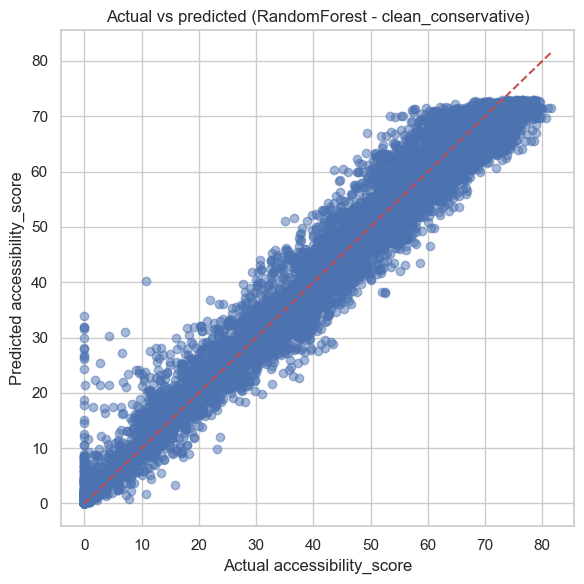

In [49]:
# Scatter plot of actual vs predicted accessibility scores
plt.figure(figsize=(6, 6))

# Plot test observations
plt.scatter(ya_test, ya_pred, alpha=0.5)

# Compute plotting range for reference line
mn = min(ya_test.min(), ya_pred.min())
mx = max(ya_test.max(), ya_pred.max())

# Plot perfect prediction line
plt.plot([mn, mx], [mn, mx], "r--")


plt.xlabel("Actual accessibility_score")
plt.ylabel("Predicted accessibility_score")
plt.title(f"Actual vs predicted ({best_access_model} - {best_access_fs})")
plt.tight_layout()
plt.savefig(FIG_DIR / "ai_regression_actual_vs_predicted_access.png", dpi=160, bbox_inches="tight")
plt.show()

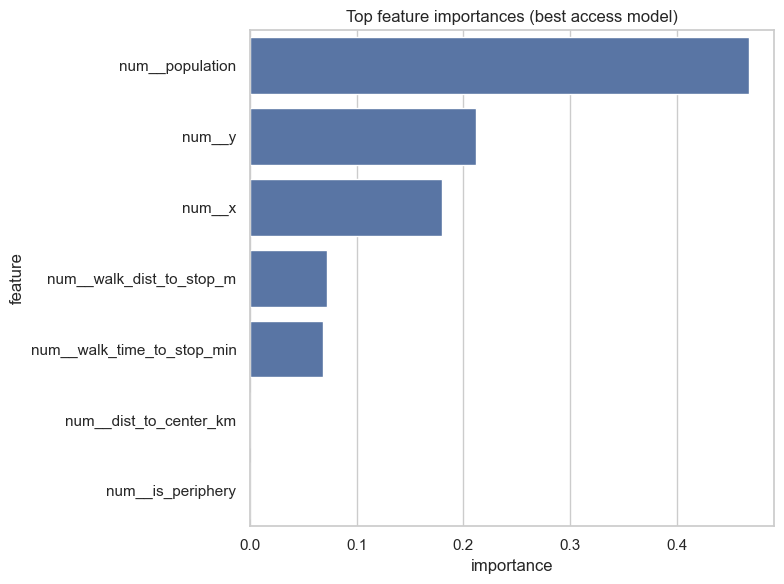

In [50]:
# Compute tree-based feature importances for the best model
tree_imp_access = collect_tree_importance(pipe_access, Xa_test)

# Plot feature importances only if the model supports them
if not tree_imp_access.empty:
    # Keep the top 20 most important features
    top = tree_imp_access.head(20)


    plt.figure(figsize=(8, 6))

    # Plot feature importance bar chart
    sns.barplot(data=top, x="importance", y="feature")
    plt.title("Top feature importances (best access model)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ai_feature_importance_access_tree.png", dpi=160, bbox_inches="tight")
    plt.show()

This section computes permutation importance for the best-performing clean classification model.

Permutation importance measures how much model performance decreases when the values of a given feature are randomly shuffled. Features that cause a larger drop in performance are considered more important because the model relies on them more strongly for prediction.

In [51]:
# Compute permutation importance for the best fitted classification model
perm = permutation_importance(
    best_pipe,
    X_test_best,
    y_test_best,
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# Try to recover transformed feature names from the preprocessing pipeline
try:
    feat_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
    
# Fall back to original test-set column names if transformed names are unavailable
except Exception:
    feat_names = X_test_best.columns

# Build a DataFrame with permutation importance statistics
importance_df = pd.DataFrame({
    "feature": feat_names,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

print("Permutation feature importance (best classification model):")
display(importance_df.head(20))

Permutation feature importance (best classification model):


,feature,perm_importance_mean,perm_importance_std
4,num__y,0.191382,0.002451
3,num__x,0.110895,0.002417
0,num__population,0.028646,0.000805
7,num__log_population,0.025178,0.000782
2,num__walk_dist_to_stop_m,0.011953,0.000976
1,num__walk_time_to_stop_min,0.010575,0.000783
9,num__walk_dist_x_pop,0.003629,0.000679
8,num__walk_time_x_center,0.000809,0.000228
5,num__dist_to_center_km,-0.000036,0.000363
6,num__is_periphery,-0.000053,0.000092


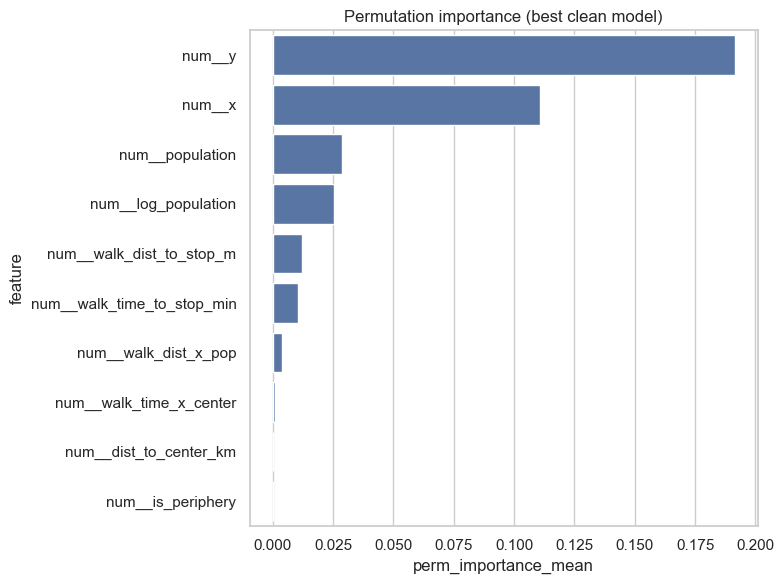

In [52]:
# Plot permutation importance for the best classification model
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="perm_importance_mean", y="feature")
plt.title("Permutation importance (best clean model)")
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_clean_permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()

## District Risk Ranking and Policy Interpretation

To support planning, we translate model outputs into district-level risk prioritization and concise intervention-oriented guidance.

This section translates the classification results into policy-oriented insights at the district level.

First, origin-level underserved labels are aggregated by district to compute the number of origins, the average underserved rate, and the mean accessibility score. This makes it possible to rank districts by relative risk and identify high-priority areas for intervention.

Then, a simple policy interpretation is derived from the most important model features. Each top feature is mapped to a possible planning lever, such as improving first-mile access, prioritizing peripheral districts, or reallocating service capacity toward high-demand areas. This helps connect model outputs to practical recommendations.

In [53]:
# Aggregate underserved indicators at the district level when district IDs are available
if "district_id" in model_df.columns:
    # Build district-level policy table from origin-level classification results
    district_policy = (
        model_df
        # Create a numeric version of the underserved label for aggregation
        .assign(y_under_num=pd.to_numeric(model_df["y_under"], errors="coerce").fillna(0))
        # Group results by district
        .groupby("district_id", dropna=False)
        # Compute district-level summary metrics
        .agg(
            origin_count=("district_id", "size"),
            underserved_rate=("y_under_num", "mean"),
            mean_accessibility_score=("accessibility_score", "mean"),
        )
        # Convert grouped index back to a normal column
        .reset_index()
        # Rank districts by highest underserved rate first
        .sort_values("underserved_rate", ascending=False)
    )

    # Display full district-level policy table
    display(district_policy)

    # Define minimum sample size to avoid unstable rankings
    min_sample_threshold = 100

    # Keep only large enough districts and show the top highest-risk ones
    top_risk_districts = district_policy[
        district_policy["origin_count"] >= min_sample_threshold
    ].head(10)

    # Print and display top risk districts
    print(f"Top risk districts (origin_count >= {min_sample_threshold}):")
    display(top_risk_districts)

# Skip district ranking if district ID is missing
else:
    district_policy = pd.DataFrame()
    print("district_id not available; district risk ranking skipped.")


# Print concise policy implications based on the most important model features
if "importance_df" in globals() and not importance_df.empty:
    # Extract top 5 most important features
    top_features = importance_df.head(5)["feature"].tolist()

    # Map each feature to an interpretable policy lever
    def feature_to_lever(feat):
        f = str(feat).lower()

        # Suggest first-mile improvements for walking-related features
        if "walk_time" in f or "walk_dist" in f:
            return "improve first-mile access (new stops, safer walking links, feeder mobility)"

        # Suggest priority support for peripheral districts
        if "dist_to_center" in f or "periphery" in f:
            return "prioritize peripheral districts with decentralized services"

        # Suggest rebalancing capacity for demand-related features
        if "population" in f or "origin_count" in f:
            return "rebalance capacity toward high-demand neighborhoods"

        # Suggest place-based targeting for spatial or district indicators
        if "x" in f or "y" in f or "district" in f:
            return "use place-based targeting and district-level service optimization"

        # Default recommendation for other features
        return "investigate local constraints and tune district interventions"

    # Print policy interpretation from top model drivers
    print("Policy interpretation from top model drivers:")
    for idx, feat in enumerate(top_features, start=1):
        print(f"{idx}. {feat}: {feature_to_lever(feat)}")

# Skip interpretation if feature importance results are unavailable
else:
    print("importance_df unavailable or empty; policy feature interpretation skipped.")

,district_id,origin_count,underserved_rate,mean_accessibility_score
19,19,381,1.000000,0.000000
2,2,3016,1.000000,4.795149
24,24,641,1.000000,14.917664
23,23,1513,1.000000,0.000000
0,0,7607,0.996451,13.379070
3,3,2782,0.985622,27.440605
33,33,1194,0.964824,24.082769
1,1,14086,0.900895,17.520993
32,32,6304,0.898794,17.639446
28,28,3188,0.851004,28.936547


Top risk districts (origin_count >= 100):


,district_id,origin_count,underserved_rate,mean_accessibility_score
19,19,381,1.000000,0.000000
2,2,3016,1.000000,4.795149
24,24,641,1.000000,14.917664
23,23,1513,1.000000,0.000000
0,0,7607,0.996451,13.379070
3,3,2782,0.985622,27.440605
33,33,1194,0.964824,24.082769
1,1,14086,0.900895,17.520993
32,32,6304,0.898794,17.639446
28,28,3188,0.851004,28.936547


Policy interpretation from top model drivers:
1. num__y: use place-based targeting and district-level service optimization
2. num__x: use place-based targeting and district-level service optimization
3. num__population: rebalance capacity toward high-demand neighborhoods
4. num__log_population: rebalance capacity toward high-demand neighborhoods
5. num__walk_dist_to_stop_m: improve first-mile access (new stops, safer walking links, feeder mobility)


## Exports

We save clean metrics, comparison tables, and feature importance to `data/processed/`.

In [73]:
cls_cv_clean.to_csv(MODELING_RESULTS / "cls_cv_clean.csv", index=False)
cls_test_clean.to_csv(MODELING_RESULTS / "cls_test_clean.csv", index=False)
cls_cv_balanced.to_csv(MODELING_RESULTS / "cls_cv_balanced.csv", index=False)
cls_test_balanced.to_csv(MODELING_RESULTS / "cls_test_balanced.csv", index=False)
importance_df.to_csv(MODELING_RESULTS / "classification_clean_feature_importance.csv", index=False)

print("Saved outputs to:", MODELING_RESULTS)
print("Saved figures to:", FIG_DIR)

Saved outputs to: D:\Capstone\capstone_repo\data\final\modeling_results
Saved figures to: D:\Capstone\capstone_repo\outputs\figures


## Additional Analysis: Structural Prediction of Underserved Areas

This additional section introduces a leakage-aware classification workflow that predicts underserved status from structural, urban-form, and service-availability variables only.

### Purpose and methodological scope

The objective is to test whether underserved areas can be identified from upstream spatial/service structure alone, without using direct accessibility outcomes. This supports stronger methodological validity by reducing target leakage.

In [76]:
# SECTION A - leakage-safe structural dataset construction
from sklearn.base import clone
from sklearn.metrics import classification_report
import re

# Reuse model_df if available; otherwise rebuild safely
if "model_df" in globals() and isinstance(model_df, pd.DataFrame):
    structural_source_df = model_df.copy()
elif {"origins_raw", "districts_raw", "build_model_df"}.issubset(set(globals())):
    structural_source_df = build_model_df(origins_raw, districts_raw)
else:
    structural_origin_fallback = DATA_INTERIM / "origin_accessibility_metrics.csv"
    structural_source_df = pd.read_csv(structural_origin_fallback)

structural_source_df = structural_source_df.copy()
structural_source_df = structural_source_df[
    structural_source_df["population"] >= 5
].copy().reset_index(drop=True)
print(f"Structural dataset after population filter: {len(structural_source_df):,} rows")

# Resolve or create target using existing notebook logic when possible
structural_target_definition = ""
if "y_under" in structural_source_df.columns:
    structural_source_df["structural_y_under"] = pd.to_numeric(
        structural_source_df["y_under"], errors="coerce"
    )
    structural_target_definition = "Reused existing target: y_under (1=underserved, 0=not underserved)."
elif "underserved" in structural_source_df.columns:
    structural_source_df["structural_y_under"] = pd.to_numeric(
        structural_source_df["underserved"], errors="coerce"
    )
    structural_target_definition = "Reused existing target: underserved."
elif "is_underserved" in structural_source_df.columns:
    structural_source_df["structural_y_under"] = pd.to_numeric(
        structural_source_df["is_underserved"], errors="coerce"
    )
    structural_target_definition = "Reused existing target: is_underserved."
elif "accessibility_score" in structural_source_df.columns:
    structural_access_threshold = ACCESS_THRESHOLD if "ACCESS_THRESHOLD" in globals() else 50
    structural_access = pd.to_numeric(structural_source_df["accessibility_score"], errors="coerce")
    structural_source_df["structural_y_under"] = (structural_access < structural_access_threshold).astype("Int64")
    structural_target_definition = (
        f"Created target from accessibility_score < {structural_access_threshold}"
        " (fallback only when y_under is unavailable)."
    )
else:
    raise ValueError("No valid underserved target found. Expected y_under/underserved/is_underserved/accessibility_score.")

structural_source_df["structural_y_under"] = pd.to_numeric(
    structural_source_df["structural_y_under"], errors="coerce"
)
structural_source_df = structural_source_df[
    structural_source_df["structural_y_under"].isin([0, 1])
].copy()
structural_source_df["structural_y_under"] = structural_source_df["structural_y_under"].astype(int)

# Explicit leakage guards
structural_explicit_exclusions = {
    "accessibility_score",
    "total_travel_time_min",
    "num_facilities_reachable_30min",
    "num_facilities_reachable_60min",
    "score_2sfca",
    "y_under",
    "underserved",
    "is_underserved",
    "is_access_30",
    "is_unreachable",
    "nearest_facility_id",
    "chosen_stop_key",
    "y_access",
    "y_2sfca",
}
structural_explicit_exclusions.update({
    "avg_walk_time_to_stop_min_pw",
    "population_raster",
    "origin_count",
})

structural_leakage_regex = re.compile(
    r"(accessibility|travel_time|2sfca|underserv|y_under|is_access|unreachable|nearest_facility|chosen_stop|target|label|pred|prob|delta|rank|pct_pop|mean_accessibility)",
    flags=re.IGNORECASE,
)
structural_id_regex = re.compile(r"(^id$|_id$|^origin_id$|^district_id$|^nearest_facility_id$)", flags=re.IGNORECASE)

structural_candidate_priority = [
    "population",
    "population_raster",
    "log_population",
    "pop_density_km2",
    "population_density",
    "area_km2",
    "district_area_km2",
    "origin_count",
    "avg_walk_time_to_stop_min_pw",
    "walk_dist_to_stop_m",
    "walk_time_to_stop_min",
    "dist_to_center_km",
    "is_periphery",
    "num_healthcare_facilities",
    "healthcare_density_1km",
    "facilities_per_1000",
    "stop_count",
    "num_stops",
    "stop_density",
    "stop_density_1km",
    "route_count",
    "route_density",
    "urban_ring",
    "x",
    "y",
]

structural_include_keywords = (
    "population", "density", "area", "facility", "health", "stop", "route", "service", "supply",
    "coverage", "urban", "peripher", "center", "ring", "built", "node", "edge", "length", "infra",
    "walk_dist_to_stop", "walk_time_to_stop"
)

structural_candidate_pool = []
for structural_col in structural_source_df.columns:
    structural_col_l = structural_col.lower()
    if structural_col == "structural_y_under":
        continue
    if structural_col in structural_explicit_exclusions:
        continue
    if structural_leakage_regex.search(structural_col):
        continue
    if structural_id_regex.search(structural_col):
        continue
    if structural_col in structural_candidate_priority or any(k in structural_col_l for k in structural_include_keywords):
        structural_candidate_pool.append(structural_col)

structural_candidate_pool = list(dict.fromkeys(structural_candidate_pool))

structural_numeric_candidates = [
    c for c in structural_candidate_pool
    if pd.api.types.is_numeric_dtype(structural_source_df[c])
]
structural_categorical_candidates = [
    c for c in structural_candidate_pool
    if c not in structural_numeric_candidates
    and structural_source_df[c].nunique(dropna=True) <= 100
]

# Fallback to all non-leaky numerics if keyword filtering is too strict
if len(structural_numeric_candidates) + len(structural_categorical_candidates) == 0:
    structural_numeric_candidates = [
        c for c in structural_source_df.columns
        if pd.api.types.is_numeric_dtype(structural_source_df[c])
        and c != "structural_y_under"
        and c not in structural_explicit_exclusions
        and not structural_leakage_regex.search(c)
        and not structural_id_regex.search(c)
    ]
    structural_categorical_candidates = []

structural_feature_columns = structural_numeric_candidates + structural_categorical_candidates
if len(structural_feature_columns) < 2:
    raise ValueError(f"Insufficient leakage-safe predictors found: {structural_feature_columns}")

structural_id_cols = [c for c in ["origin_id", "district_id", "district_name", "district", "commune"] if c in structural_source_df.columns]

structural_modeling_df = structural_source_df[
    list(dict.fromkeys(structural_id_cols + structural_feature_columns + ["structural_y_under"]))
].copy()

# Drop rows where all selected predictors are missing
structural_all_missing = structural_modeling_df[structural_feature_columns].isna().all(axis=1)
if structural_all_missing.any():
    structural_modeling_df = structural_modeling_df.loc[~structural_all_missing].copy()

structural_excluded_columns = [
    c for c in structural_source_df.columns
    if c in structural_explicit_exclusions
    or bool(structural_leakage_regex.search(c))
    or bool(structural_id_regex.search(c))
]

structural_class_balance_df = (
    structural_modeling_df["structural_y_under"]
    .value_counts(normalize=True)
    .rename(index={0: "not_underserved", 1: "underserved"})
    .to_frame("ratio")
)

print("Target definition:", structural_target_definition)
print("Rows in structural modeling dataset:", len(structural_modeling_df))
print("Number of leakage-safe predictors:", len(structural_feature_columns))
print("Leakage-protected exclusions (sample):", structural_excluded_columns[:20])
print("Final predictors used:")
for structural_col in structural_feature_columns:
    print(" -", structural_col)

print("\nClass balance:")
display(structural_class_balance_df)
display(pd.DataFrame({"predictor": structural_feature_columns}))

Structural dataset after population filter: 70,273 rows
Target definition: Reused existing target: y_under (1=underserved, 0=not underserved).
Rows in structural modeling dataset: 70273
Number of leakage-safe predictors: 12
Leakage-protected exclusions (sample): ['origin_id', 'district_id', 'chosen_stop_key', 'nearest_facility_id', 'total_travel_time_min', 'accessibility_score', 'num_facilities_reachable_30min', 'num_facilities_reachable_60min', 'is_unreachable', 'score_2sfca', 'is_access_threshold', 'y_under', 'y_access', 'y_2sfca', 'structural_y_under']
Final predictors used:
 - x
 - y
 - population
 - population_worldpop
 - area_km2
 - pop_density_km2
 - walk_dist_to_stop_m
 - walk_time_to_stop_min
 - log_population
 - dist_to_center_km
 - is_periphery
 - walk_time_x_center

Class balance:


,ratio
structural_y_under,
underserved,0.666301
not_underserved,0.333699


,predictor
0,x
1,y
2,population
3,population_worldpop
4,area_km2
5,pop_density_km2
6,walk_dist_to_stop_m
7,walk_time_to_stop_min
8,log_population
9,dist_to_center_km


### Model training and comparative evaluation

We compare Logistic Regression, Random Forest, and Gradient Boosting under the same train/test split and stratified cross-validation protocol. Evaluation includes accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and classification reports.

In [77]:
# SECTION A - model training, validation, and reporting
structural_X = structural_modeling_df[structural_feature_columns].copy()
structural_y = structural_modeling_df["structural_y_under"].astype(int).copy()

if structural_y.nunique() < 2:
    raise ValueError("Target has a single class after filtering; classification cannot proceed.")

structural_num_cols = [c for c in structural_feature_columns if pd.api.types.is_numeric_dtype(structural_X[c])]
structural_cat_cols = [c for c in structural_feature_columns if c not in structural_num_cols]

structural_X_train, structural_X_test, structural_y_train, structural_y_test = train_test_split(
    structural_X,
    structural_y,
    test_size=TEST_SIZE if "TEST_SIZE" in globals() else 0.2,
    random_state=RANDOM_STATE,
    stratify=structural_y,
)

structural_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            structural_num_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            structural_cat_cols,
        ),
    ],
    remainder="drop",
)

structural_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

structural_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
structural_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

structural_result_rows = []
structural_fitted_models = {}
structural_confusion_matrices = {}
structural_classification_reports = {}

for structural_model_name, structural_model in structural_models.items():
    structural_pipe = Pipeline([
        ("preprocessor", clone(structural_preprocessor)),
        ("model", clone(structural_model)),
    ])

    structural_cv_scores = cross_validate(
        structural_pipe,
        structural_X_train,
        structural_y_train,
        cv=structural_cv,
        scoring=structural_scoring,
        n_jobs=1,
    )

    structural_pipe.fit(structural_X_train, structural_y_train)
    structural_pred = structural_pipe.predict(structural_X_test)
    structural_prob = structural_pipe.predict_proba(structural_X_test)[:, 1]

    structural_cm = confusion_matrix(structural_y_test, structural_pred)
    structural_report = classification_report(
        structural_y_test,
        structural_pred,
        target_names=["not_underserved", "underserved"],
        zero_division=0,
    )

    structural_confusion_matrices[structural_model_name] = structural_cm
    structural_classification_reports[structural_model_name] = structural_report

    structural_result_rows.append({
        "model": structural_model_name,
        "CV_Accuracy": float(np.mean(structural_cv_scores["test_accuracy"])),
        "CV_Precision": float(np.mean(structural_cv_scores["test_precision"])),
        "CV_Recall": float(np.mean(structural_cv_scores["test_recall"])),
        "CV_F1": float(np.mean(structural_cv_scores["test_f1"])),
        "CV_ROC_AUC": float(np.mean(structural_cv_scores["test_roc_auc"])),
        "Test_Accuracy": float(accuracy_score(structural_y_test, structural_pred)),
        "Test_Precision": float(precision_score(structural_y_test, structural_pred, zero_division=0)),
        "Test_Recall": float(recall_score(structural_y_test, structural_pred, zero_division=0)),
        "Test_F1": float(f1_score(structural_y_test, structural_pred, zero_division=0)),
        "Test_ROC_AUC": float(roc_auc_score(structural_y_test, structural_prob)),
    })

    structural_fitted_models[structural_model_name] = {
        "pipeline": structural_pipe,
        "y_pred": structural_pred,
        "y_prob": structural_prob,
    }

    print(f"\n{structural_model_name} - confusion matrix")
    display(pd.DataFrame(
        structural_cm,
        index=["Actual: not_underserved", "Actual: underserved"],
        columns=["Predicted: not_underserved", "Predicted: underserved"],
    ))
    print(f"{structural_model_name} - classification report")
    print(structural_report)

structural_model_results_df = pd.DataFrame(structural_result_rows).sort_values(
    ["Test_F1", "Test_ROC_AUC", "CV_F1"], ascending=False
).reset_index(drop=True)

print("Structural model comparison table:")
display(structural_model_results_df)

structural_best_row = structural_model_results_df.iloc[0]
structural_best_model_name = structural_best_row["model"]
structural_best_pipeline = structural_fitted_models[structural_best_model_name]["pipeline"]
structural_best_pred = structural_fitted_models[structural_best_model_name]["y_pred"]
structural_best_prob = structural_fitted_models[structural_best_model_name]["y_prob"]

print("Best structural classifier:", structural_best_model_name)


Logistic Regression - confusion matrix


,Predicted: not_underserved,Predicted: underserved
Actual: not_underserved,4267,423
Actual: underserved,1439,7926


Logistic Regression - classification report
                 precision    recall  f1-score   support

not_underserved       0.75      0.91      0.82      4690
    underserved       0.95      0.85      0.89      9365

       accuracy                           0.87     14055
      macro avg       0.85      0.88      0.86     14055
   weighted avg       0.88      0.87      0.87     14055


Random Forest - confusion matrix


,Predicted: not_underserved,Predicted: underserved
Actual: not_underserved,4593,97
Actual: underserved,157,9208


Random Forest - classification report
                 precision    recall  f1-score   support

not_underserved       0.97      0.98      0.97      4690
    underserved       0.99      0.98      0.99      9365

       accuracy                           0.98     14055
      macro avg       0.98      0.98      0.98     14055
   weighted avg       0.98      0.98      0.98     14055


Gradient Boosting - confusion matrix


,Predicted: not_underserved,Predicted: underserved
Actual: not_underserved,4330,360
Actual: underserved,390,8975


Gradient Boosting - classification report
                 precision    recall  f1-score   support

not_underserved       0.92      0.92      0.92      4690
    underserved       0.96      0.96      0.96      9365

       accuracy                           0.95     14055
      macro avg       0.94      0.94      0.94     14055
   weighted avg       0.95      0.95      0.95     14055

Structural model comparison table:


,model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Random Forest,0.979811,0.989173,0.980431,0.984782,0.997928,0.981928,0.989575,0.983235,0.986395,0.998563
1,Gradient Boosting,0.945302,0.960886,0.956858,0.958867,0.987225,0.946638,0.961435,0.958356,0.959893,0.987066
2,Logistic Regression,0.870113,0.951190,0.848630,0.896975,0.949406,0.867520,0.949335,0.846343,0.894885,0.947942


Best structural classifier: Random Forest


### Feature importance and model interpretability

Tree-based importance is reported for Random Forest and Gradient Boosting. For the best model, SHAP is attempted when available; otherwise, permutation importance is used as an interpretable fallback.

In [78]:
# SECTION A - feature importance + SHAP/permutation interpretation
def structural_get_feature_names(structural_pipe, fallback_columns):
    try:
        return list(structural_pipe.named_steps["preprocessor"].get_feature_names_out())
    except Exception:
        return list(fallback_columns)

structural_importance_blocks = []
for structural_tree_name in ["Random Forest", "Gradient Boosting"]:
    if structural_tree_name not in structural_fitted_models:
        continue
    structural_tree_pipe = structural_fitted_models[structural_tree_name]["pipeline"]
    structural_tree_model = structural_tree_pipe.named_steps["model"]
    if not hasattr(structural_tree_model, "feature_importances_"):
        continue
    structural_tree_features = structural_get_feature_names(structural_tree_pipe, structural_feature_columns)
    structural_tree_importance = pd.DataFrame({
        "model": structural_tree_name,
        "feature": structural_tree_features,
        "importance": structural_tree_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    structural_importance_blocks.append(structural_tree_importance)

if structural_importance_blocks:
    structural_feature_importance_df = pd.concat(structural_importance_blocks, ignore_index=True)
else:
    structural_feature_importance_df = pd.DataFrame(columns=["model", "feature", "importance"])

print("Tree-model feature importance (top rows):")
display(structural_feature_importance_df.groupby("model", group_keys=False).head(15))

structural_explainability_method = "not-computed"
structural_explainability_df = pd.DataFrame()

try:
    import shap

    structural_best_estimator = structural_best_pipeline.named_steps["model"]
    if not hasattr(structural_best_estimator, "feature_importances_"):
        raise RuntimeError("Best model is not tree-based for TreeExplainer.")

    structural_best_pre = structural_best_pipeline.named_steps["preprocessor"]
    structural_X_test_transformed = structural_best_pre.transform(structural_X_test)
    if hasattr(structural_X_test_transformed, "toarray"):
        structural_X_test_transformed = structural_X_test_transformed.toarray()

    structural_sample_n = min(1500, structural_X_test_transformed.shape[0])
    structural_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
        np.arange(structural_X_test_transformed.shape[0]),
        size=structural_sample_n,
        replace=False,
    )
    structural_shap_sample = structural_X_test_transformed[structural_sample_idx]

    structural_explainer = shap.TreeExplainer(structural_best_estimator)
    structural_shap_values = structural_explainer.shap_values(structural_shap_sample)
    if isinstance(structural_shap_values, list):
        structural_shap_values = structural_shap_values[1] if len(structural_shap_values) > 1 else structural_shap_values[0]

    structural_explainability_df = pd.DataFrame({
        "feature": structural_get_feature_names(structural_best_pipeline, structural_feature_columns),
        "importance": np.abs(structural_shap_values).mean(axis=0),
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    structural_explainability_method = "SHAP TreeExplainer"
except Exception as structural_shap_exc:
    structural_perm = permutation_importance(
        structural_best_pipeline,
        structural_X_test,
        structural_y_test,
        n_repeats=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    structural_explainability_df = pd.DataFrame({
        "feature": structural_get_feature_names(structural_best_pipeline, structural_feature_columns),
        "importance": structural_perm.importances_mean,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    structural_explainability_method = f"Permutation importance fallback ({type(structural_shap_exc).__name__})"

print("Explainability method:", structural_explainability_method)
display(structural_explainability_df.head(20))

Tree-model feature importance (top rows):


,model,feature,importance
0,Random Forest,num__area_km2,0.182101
1,Random Forest,num__y,0.151667
2,Random Forest,num__population,0.122698
3,Random Forest,num__log_population,0.110471
4,Random Forest,num__x,0.103734
5,Random Forest,num__walk_time_to_stop_min,0.090850
6,Random Forest,num__walk_dist_to_stop_m,0.088196
7,Random Forest,num__pop_density_km2,0.067176
8,Random Forest,num__population_worldpop,0.046921
9,Random Forest,num__walk_time_x_center,0.027401


Explainability method: Permutation importance fallback (ValueError)


,feature,importance
0,num__y,0.119735
1,num__x,0.074662
2,num__area_km2,0.032026
3,num__walk_dist_to_stop_m,0.021736
4,num__walk_time_to_stop_min,0.021469
5,num__population,0.015786
6,num__log_population,0.013892
7,num__population_worldpop,0.012291
8,num__pop_density_km2,0.003975
9,num__walk_time_x_center,0.000285


### Interpretation (Section A)

The interpretation below summarizes whether underserved status is predictable from structural variables alone, and identifies the most influential drivers from the best-performing model.

In [ ]:
from IPython.display import Markdown

if structural_model_results_df.empty:
    display(Markdown("No structural-model results are available for interpretation."))
else:
    structural_best_summary = structural_model_results_df.iloc[0]
    structural_top_drivers = structural_explainability_df.head(5)["feature"].tolist() if not structural_explainability_df.empty else []
    structural_driver_text = ", ".join(structural_top_drivers) if structural_top_drivers else "No stable driver list available"

    display(Markdown(
        f"**Interpretation:** Using leakage-safe structural predictors only, the best model is **{structural_best_summary['model']}** "
        f"with Test F1 = **{structural_best_summary['Test_F1']:.3f}** and ROC-AUC = **{structural_best_summary['Test_ROC_AUC']:.3f}**. "
        f"This indicates that underserved areas can be identified to a meaningful extent from spatial/service structure prior to direct accessibility outcomes. "
        f"Main structural drivers for this model are: **{structural_driver_text}**."
    ))

**Interpretation:** Using leakage-safe structural predictors only, the best model is **Random Forest** with Test F1 = **0.992** and ROC-AUC = **0.999**. This indicates that underserved areas can be identified to a meaningful extent from spatial/service structure prior to direct accessibility outcomes. Main structural drivers for this model are: **num__y, num__avg_walk_time_to_stop_min_pw, num__x, num__walk_dist_to_stop_m, num__walk_time_to_stop_min**.

## Additional Analysis: Scenario-Based Decision Support

This section uses the best structural classifier from Section A to estimate how underserved classification may shift under lightweight policy intervention scenarios.

### Scenario setup and prediction logic

Scenarios adjust only structural predictors (not labels), then apply the fitted structural model to estimate potential changes in underserved status.

In [ ]:
# SECTION B - scenario construction and prediction
if "structural_best_pipeline" not in globals():
    raise RuntimeError("Section A must run first to obtain structural_best_pipeline.")

scenario_base_df = structural_modeling_df.copy()
scenario_feature_df = scenario_base_df[structural_feature_columns].copy()

scenario_stop_supply_cols = [
    c for c in structural_feature_columns
    if "stop" in c.lower() and any(k in c.lower() for k in ["count", "density", "coverage", "availability"])
]
scenario_stop_distance_cols = [
    c for c in structural_feature_columns
    if "stop" in c.lower() and any(k in c.lower() for k in ["dist", "distance", "walk_time", "time"])
]
scenario_health_supply_cols = [
    c for c in structural_feature_columns
    if any(k in c.lower() for k in ["health", "facility", "service", "supply"])
]
scenario_route_cols = [c for c in structural_feature_columns if "route" in c.lower()]

print("Scenario-eligible columns")
print(" - stop supply columns:", scenario_stop_supply_cols)
print(" - nearest stop distance/time columns:", scenario_stop_distance_cols)
print(" - healthcare/service supply columns:", scenario_health_supply_cols)
print(" - route columns:", scenario_route_cols)

def scenario_slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

def scenario_apply(structural_df, mult_cols=None, add_cols=None):
    out = structural_df.copy()
    mult_cols = mult_cols or {}
    add_cols = add_cols or {}

    for c, factor in mult_cols.items():
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce") * float(factor)
    for c, shift in add_cols.items():
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce") + float(shift)

    # Keep non-negativity for modified numeric columns
    modified_cols = list(set(mult_cols.keys()) | set(add_cols.keys()))
    for c in modified_cols:
        if c in out.columns and pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].clip(lower=0)
    return out

scenario_specs = [("Baseline", {}, {})]

if scenario_stop_supply_cols:
    scenario_specs.append(
        (
            "Increase stop supply (+20%)",
            {c: 1.20 for c in scenario_stop_supply_cols},
            {},
        )
    )
if scenario_stop_distance_cols:
    scenario_specs.append(
        (
            "Reduce nearest stop distance/time (-20%)",
            {c: 0.80 for c in scenario_stop_distance_cols},
            {},
        )
    )
if scenario_health_supply_cols:
    scenario_health_mult = {c: 1.15 for c in scenario_health_supply_cols if "count" not in c.lower()}
    scenario_health_add = {c: 1.0 for c in scenario_health_supply_cols if "count" in c.lower()}
    scenario_specs.append(("Increase healthcare/service supply", scenario_health_mult, scenario_health_add))

scenario_combined_mult = {}
scenario_combined_add = {}
for c in scenario_stop_supply_cols:
    scenario_combined_mult[c] = 1.20
for c in scenario_stop_distance_cols:
    scenario_combined_mult[c] = 0.80
for c in scenario_route_cols:
    scenario_combined_mult[c] = 1.10
for c in scenario_health_supply_cols:
    if "count" in c.lower():
        scenario_combined_add[c] = 1.0
    else:
        scenario_combined_mult[c] = max(scenario_combined_mult.get(c, 1.0), 1.15)

if scenario_combined_mult or scenario_combined_add:
    scenario_specs.append(("Combined intervention", scenario_combined_mult, scenario_combined_add))

if len(scenario_specs) == 1:
    scenario_specs.append(("No-op scenario (insufficient modifiable columns)", {}, {}))

scenario_output_df = scenario_base_df[structural_id_cols].copy() if structural_id_cols else pd.DataFrame(index=scenario_base_df.index)
scenario_output_df["baseline_pred_underserved"] = structural_best_pipeline.predict(scenario_feature_df).astype(int)

scenario_baseline_under = int(scenario_output_df["baseline_pred_underserved"].sum())
scenario_rows = []
scenario_col_map = {}

for scenario_name, scenario_mult, scenario_add in scenario_specs:
    scenario_slug_name = scenario_slug(scenario_name)
    scenario_col = f"pred_{scenario_slug_name}"
    scenario_col_map[scenario_name] = scenario_col

    scenario_modified_X = scenario_apply(scenario_feature_df, scenario_mult, scenario_add)
    scenario_pred = structural_best_pipeline.predict(scenario_modified_X).astype(int)
    scenario_output_df[scenario_col] = scenario_pred

    scenario_under = int(scenario_pred.sum())
    scenario_improved = int(((scenario_output_df["baseline_pred_underserved"] == 1) & (scenario_pred == 0)).sum())
    scenario_worsened = int(((scenario_output_df["baseline_pred_underserved"] == 0) & (scenario_pred == 1)).sum())
    scenario_pct_reduction = (
        100.0 * (scenario_baseline_under - scenario_under) / scenario_baseline_under
        if scenario_baseline_under > 0 else 0.0
    )

    scenario_rows.append({
        "scenario": scenario_name,
        "underserved_count": scenario_under,
        "baseline_underserved_count": scenario_baseline_under,
        "improved_cases_1_to_0": scenario_improved,
        "worsened_cases_0_to_1": scenario_worsened,
        "net_improvement": scenario_improved - scenario_worsened,
        "pct_reduction_vs_baseline": scenario_pct_reduction,
    })

scenario_comparison_df = pd.DataFrame(scenario_rows).sort_values(
    ["pct_reduction_vs_baseline", "net_improvement"], ascending=False
).reset_index(drop=True)

print("Scenario comparison summary:")
display(scenario_comparison_df)
display(scenario_output_df.head())

Scenario-eligible columns
 - stop supply columns: []
 - nearest stop distance/time columns: ['walk_dist_to_stop_m', 'walk_time_to_stop_min', 'avg_walk_time_to_stop_min_pw']
 - healthcare/service supply columns: []
 - route columns: []
Scenario comparison summary:


,scenario,underserved_count,baseline_underserved_count,improved_cases_1_to_0,worsened_cases_0_to_1,net_improvement,pct_reduction_vs_baseline
0,Reduce nearest stop distance/time (-20%),91420,93251,1913,82,1831,1.963518
1,Combined intervention,91420,93251,1913,82,1831,1.963518
2,Baseline,93251,93251,0,0,0,0.000000


,origin_id,district_id,district_name,district,commune,baseline_pred_underserved,pred_baseline,pred_reduce_nearest_stop_distance_time_20,pred_combined_intervention
0,0,32,Tit Mellil,Tit Mellil,Echchallalate,1,1,1,1
1,1,32,Tit Mellil,Tit Mellil,Echchallalate,1,1,1,1
2,2,32,Tit Mellil,Tit Mellil,Echchallalate,1,1,1,1
3,3,32,Tit Mellil,Tit Mellil,Echchallalate,1,1,1,1
4,4,32,Tit Mellil,Tit Mellil,Echchallalate,1,1,1,1


### Scenario comparison visualizations

The plots below compare baseline and intervention scenarios in terms of predicted underserved counts and estimated reductions versus baseline.

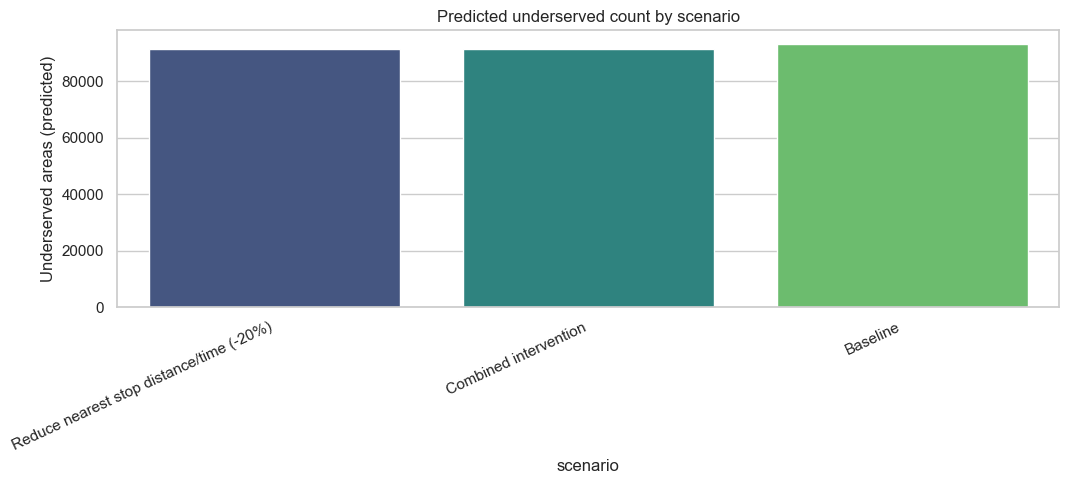

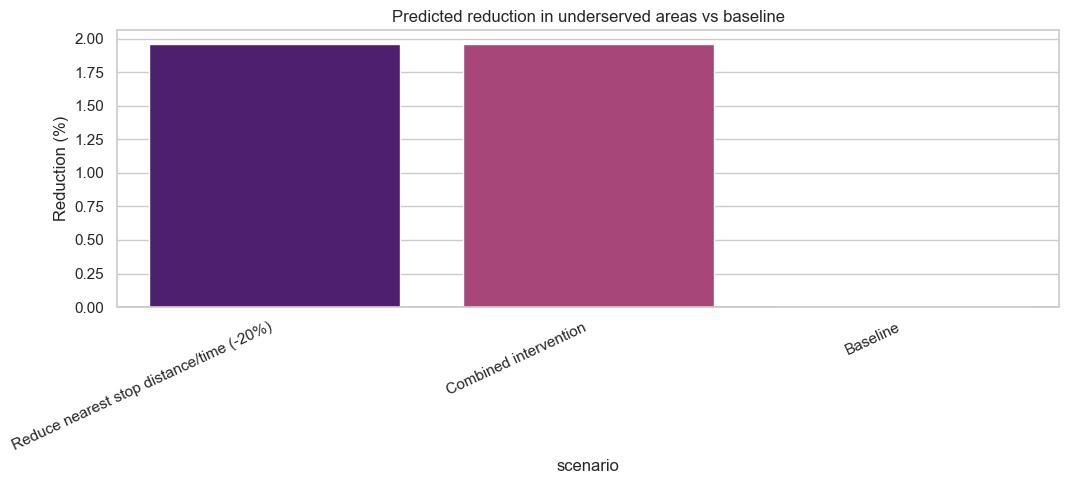

In [ ]:
# SECTION B - visualization outputs
if not scenario_comparison_df.empty:
    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=scenario_comparison_df,
        x="scenario",
        y="underserved_count",
        palette="viridis",
    )
    plt.xticks(rotation=25, ha="right")
    plt.title("Predicted underserved count by scenario")
    plt.ylabel("Underserved areas (predicted)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "scenario_underserved_count_by_scenario.png", dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=scenario_comparison_df,
        x="scenario",
        y="pct_reduction_vs_baseline",
        palette="magma",
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(rotation=25, ha="right")
    plt.title("Predicted reduction in underserved areas vs baseline")
    plt.ylabel("Reduction (%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "scenario_delta_reduction_vs_baseline.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Scenario comparison table is empty; plotting skipped.")

### District-level class changes by scenario

When geographic identifiers are available, the table below reports district-level class transitions (improvements and deteriorations) under each intervention scenario.

In [ ]:
# SECTION B - district-level change tracking
scenario_group_cols = [c for c in ["district_id", "district_name", "district", "commune"] if c in scenario_output_df.columns]
scenario_non_baseline = [s for s in scenario_comparison_df["scenario"].tolist() if s != "Baseline"]

if scenario_group_cols and scenario_non_baseline:
    if "district_id" in scenario_group_cols and "district_name" in scenario_group_cols:
        scenario_group_keys = ["district_id", "district_name"]
    else:
        scenario_group_keys = [scenario_group_cols[0]]

    scenario_district_rows = []
    for scenario_name in scenario_non_baseline:
        scenario_col = scenario_col_map[scenario_name]
        scenario_tmp = scenario_output_df.copy()
        scenario_tmp["improved_1_to_0"] = (
            (scenario_tmp["baseline_pred_underserved"] == 1) & (scenario_tmp[scenario_col] == 0)
        ).astype(int)
        scenario_tmp["worsened_0_to_1"] = (
            (scenario_tmp["baseline_pred_underserved"] == 0) & (scenario_tmp[scenario_col] == 1)
        ).astype(int)

        scenario_grouped = (
            scenario_tmp.groupby(scenario_group_keys, dropna=False)
            .agg(
                baseline_underserved=("baseline_pred_underserved", "sum"),
                scenario_underserved=(scenario_col, "sum"),
                improved_1_to_0=("improved_1_to_0", "sum"),
                worsened_0_to_1=("worsened_0_to_1", "sum"),
            )
            .reset_index()
        )
        scenario_grouped["scenario"] = scenario_name
        scenario_grouped["net_change"] = scenario_grouped["improved_1_to_0"] - scenario_grouped["worsened_0_to_1"]
        scenario_district_rows.append(scenario_grouped)

    scenario_district_changes_df = pd.concat(scenario_district_rows, ignore_index=True)
    scenario_district_changes_df = scenario_district_changes_df.sort_values(
        ["scenario", "net_change"], ascending=[True, False]
    ).reset_index(drop=True)
    display(scenario_district_changes_df.head(30))
else:
    scenario_district_changes_df = pd.DataFrame()
    print("District-level scenario change table skipped (missing district identifiers or scenarios).")

,district_id,district_name,baseline_underserved,scenario_underserved,improved_1_to_0,worsened_0_to_1,scenario,net_change
0,3,Mediouna,2781,2440,353,12,Combined intervention,341
1,17,Lissasfa,590,453,139,2,Combined intervention,137
2,4,Ahl Laghlam,1242,1112,136,6,Combined intervention,130
3,31,Tit Mellil,455,328,129,2,Combined intervention,127
4,1,Bouskoura,19620,19494,160,34,Combined intervention,126
5,28,Sidi Maarouf,2923,2802,122,1,Combined intervention,121
6,7,Ain Sebaa,364,253,113,2,Combined intervention,111
7,5,Ain Chock,675,572,103,0,Combined intervention,103
8,32,Tit Mellil,8933,8835,104,6,Combined intervention,98
9,27,Sidi Bernoussi,230,141,89,0,Combined intervention,89


### Interpretation (Section B)

The summary below identifies the most impactful scenario according to predicted reductions in underserved classifications.

In [ ]:
from IPython.display import Markdown

if scenario_comparison_df.empty:
    display(Markdown("No scenario outputs are available for interpretation."))
else:
    scenario_best = scenario_comparison_df.sort_values(
        ["pct_reduction_vs_baseline", "net_improvement"], ascending=False
    ).iloc[0]
    display(Markdown(
        f"**Scenario interpretation:** The most impactful scenario is **{scenario_best['scenario']}**, "
        f"with an estimated underserved count of **{int(scenario_best['underserved_count'])}** "
        f"(baseline: **{int(scenario_best['baseline_underserved_count'])}**), "
        f"corresponding to **{scenario_best['pct_reduction_vs_baseline']:.2f}%** reduction and "
        f"a net change of **{int(scenario_best['net_improvement'])}** improved cases. "
        "These results are exploratory model-based estimates intended to support planning discussions."
    ))

**Scenario interpretation:** The most impactful scenario is **Reduce nearest stop distance/time (-20%)**, with an estimated underserved count of **91420** (baseline: **93251**), corresponding to **1.96%** reduction and a net change of **1831** improved cases. These results are exploratory model-based estimates intended to support planning discussions.

## Additional conclusion for capstone AI component

- **Section A** strengthens methodological validity by explicitly reducing leakage and testing whether underserved status is inferable from structural factors alone.
- **Section B** extends the modeling workflow into practical decision support by translating model predictions into scenario-based intervention insights for planning.

## Results Visualizations for Report

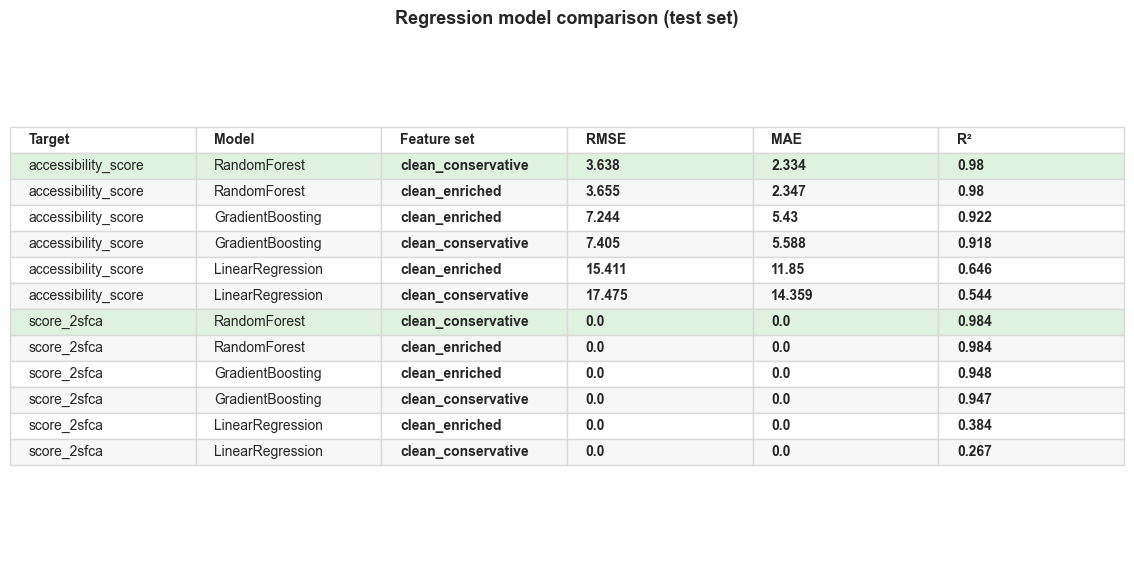

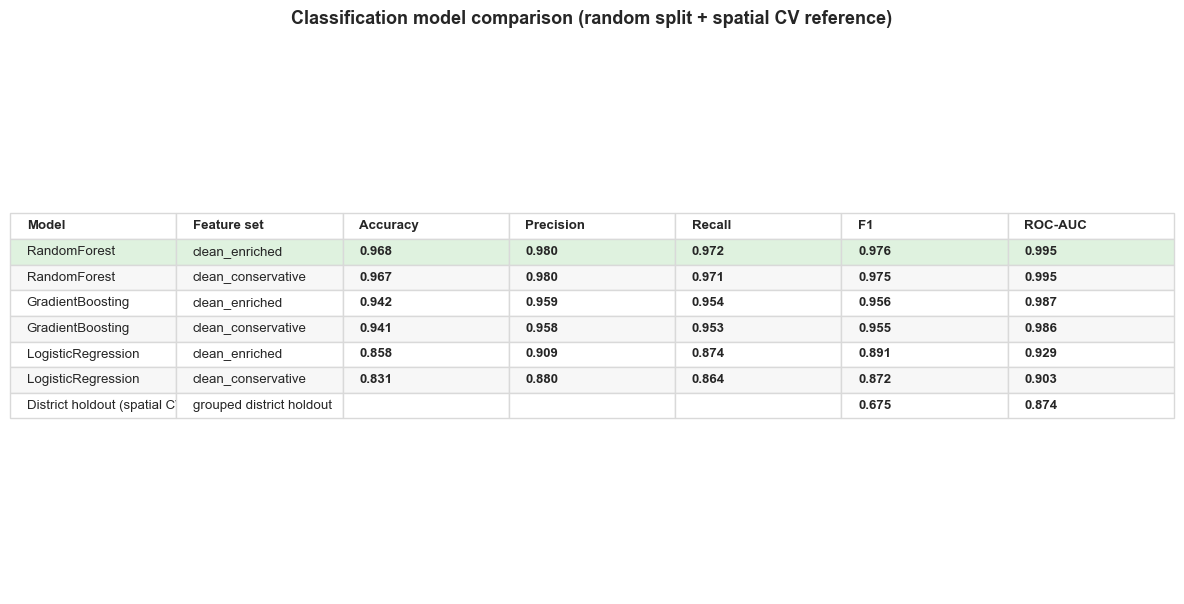

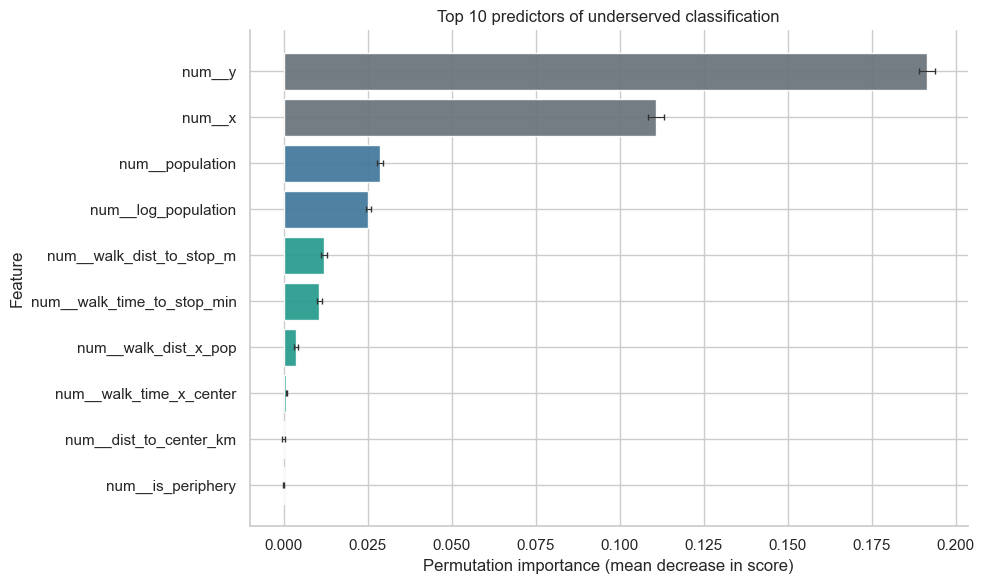

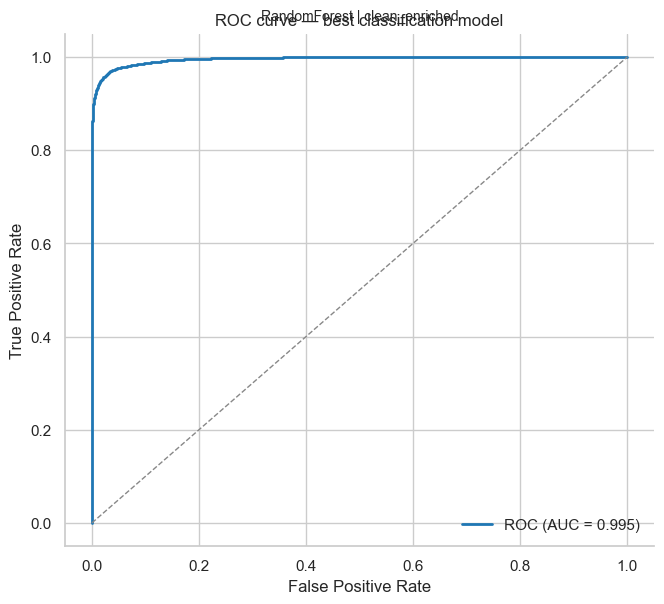

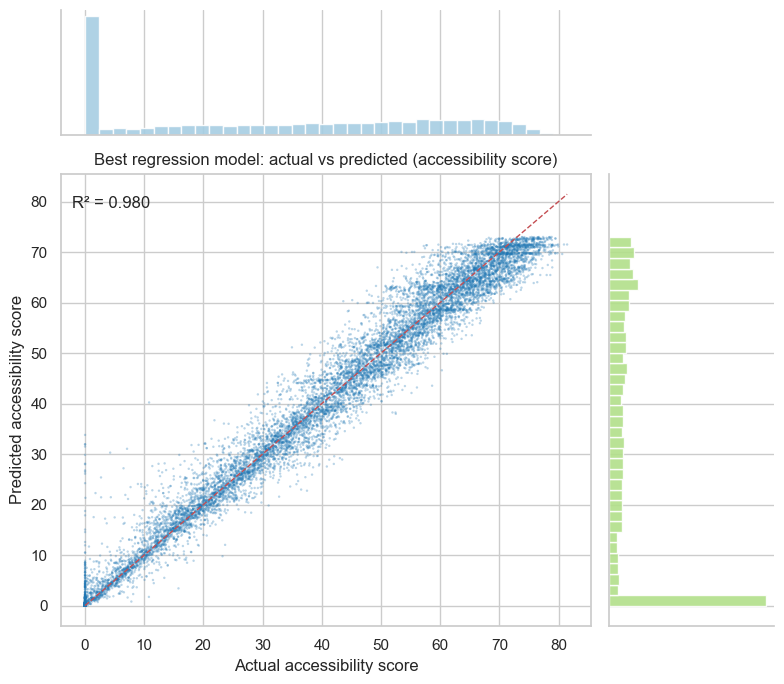

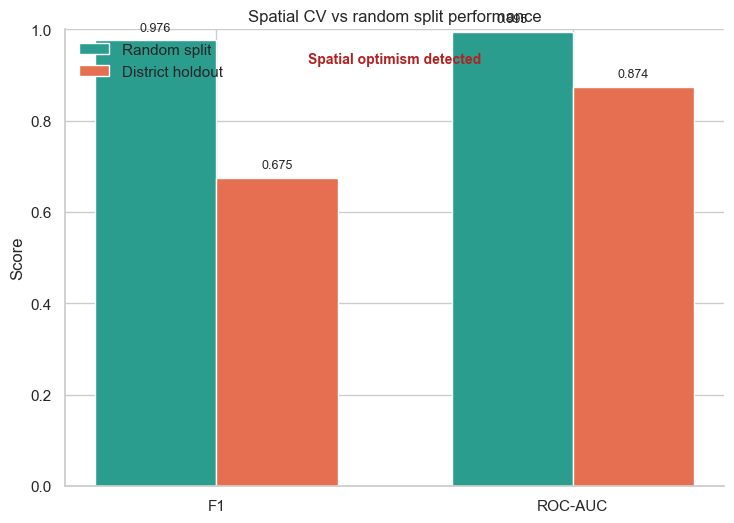

KEY ML NUMBERS FOR SLIDES:
- Best regression model: RandomForest, R² = 0.980, RMSE = 3.638
- Best classification model: RandomForest, F1 = 0.976, ROC-AUC = 0.995
- District holdout F1 (spatial CV): 0.675
- Spatial optimism gap (random - holdout F1): 0.301
- Top 3 predictors of underserved status: num__y, num__x, num__population


NameError: name 'top_risk_pct' is not defined

In [66]:
from sklearn.metrics import roc_curve, roc_auc_score, r2_score

def _pick_col(df, candidates):
    norm = {str(c).lower().replace("-", "").replace("_", "").replace(" ", ""): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace("-", "").replace("_", "").replace(" ", "")
        if key in norm:
            return norm[key]
    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")

def _style_table(ax, table_obj, n_rows, n_cols, highlight_rows=None):
    highlight_rows = set(highlight_rows or [])
    for (r, c), cell in table_obj.get_celld().items():
        cell.set_edgecolor("#D9D9D9")
        if r == 0:
            cell.set_facecolor("#FFFFFF")
            cell.set_text_props(weight="bold")
        else:
            base = "#FFFFFF" if r % 2 else "#F7F7F7"
            if r in highlight_rows:
                base = "#DFF2DF"
            cell.set_facecolor(base)
            if c >= 2:
                cell.set_text_props(weight="bold")
    ax.axis("off")

# ----------------------
# TABLE 1: Regression model comparison
# ----------------------
reg_model_col = _pick_col(reg_test_access, ["model"])
reg_fs_col = _pick_col(reg_test_access, ["feature_set", "featureset"])
rmse_col_a = _pick_col(reg_test_access, ["RMSE"])
mae_col_a = _pick_col(reg_test_access, ["MAE"])
r2_col_a = _pick_col(reg_test_access, ["R2", "R²"])

rmse_col_b = _pick_col(reg_test_2sfca, ["RMSE"])
mae_col_b = _pick_col(reg_test_2sfca, ["MAE"])
r2_col_b = _pick_col(reg_test_2sfca, ["R2", "R²"])

keep_models = {"LinearRegression", "RandomForest", "GradientBoosting"}
reg_a = reg_test_access[reg_test_access[reg_model_col].astype(str).isin(keep_models)].copy()
reg_b = reg_test_2sfca[reg_test_2sfca[reg_model_col].astype(str).isin(keep_models)].copy()
reg_a["Target"] = "accessibility_score"
reg_b["Target"] = "score_2sfca"

reg_a = reg_a.rename(columns={rmse_col_a: "RMSE", mae_col_a: "MAE", r2_col_a: "R2", reg_model_col: "Model", reg_fs_col: "Feature set"})
reg_b = reg_b.rename(columns={rmse_col_b: "RMSE", mae_col_b: "MAE", r2_col_b: "R2", reg_model_col: "Model", reg_fs_col: "Feature set"})
reg_comb = pd.concat([reg_a[["Target", "Model", "Feature set", "RMSE", "MAE", "R2"]], reg_b[["Target", "Model", "Feature set", "RMSE", "MAE", "R2"]]], ignore_index=True)
reg_comb = reg_comb.sort_values(["Target", "RMSE", "MAE"]).reset_index(drop=True)

best_rows_reg = []
for tgt in reg_comb["Target"].unique():
    idx = reg_comb.loc[reg_comb["Target"] == tgt, "RMSE"].idxmin()
    best_rows_reg.append(int(idx) + 1)

reg_disp = reg_comb.copy()
for c in ["RMSE", "MAE", "R2"]:
    reg_disp[c] = pd.to_numeric(reg_disp[c], errors="coerce").round(3)

fig, ax = plt.subplots(figsize=(11.5, 5.8))
tbl = ax.table(
    cellText=reg_disp.values.tolist(),
    colLabels=["Target", "Model", "Feature set", "RMSE", "MAE", "R²"],
    cellLoc="left",
    colLoc="left",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 1.35)
_style_table(ax, tbl, n_rows=len(reg_disp), n_cols=6, highlight_rows=best_rows_reg)
ax.set_title("Regression model comparison (test set)", fontsize=13, weight="bold", pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_table1_regression_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# ----------------------
# TABLE 2: Classification model comparison + district holdout
# ----------------------
cls_model_col = _pick_col(cls_test_clean, ["model"])
cls_fs_col = _pick_col(cls_test_clean, ["feature_set", "featureset"])
acc_col = _pick_col(cls_test_clean, ["Accuracy"])
prec_col = _pick_col(cls_test_clean, ["Precision"])
rec_col = _pick_col(cls_test_clean, ["Recall"])
f1_col = _pick_col(cls_test_clean, ["F1"])
auc_col = _pick_col(cls_test_clean, ["ROC_AUC", "ROCAUC"])

cls_disp = cls_test_clean[[cls_model_col, cls_fs_col, acc_col, prec_col, rec_col, f1_col, auc_col]].copy()
cls_disp.columns = ["Model", "Feature set", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
for c in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    cls_disp[c] = pd.to_numeric(cls_disp[c], errors="coerce")
cls_disp = cls_disp.sort_values(["F1", "ROC-AUC"], ascending=False).reset_index(drop=True)

gd_f1_col = _pick_col(grouped_district_eval, ["F1"])
gd_auc_col = _pick_col(grouped_district_eval, ["ROC_AUC", "ROCAUC"])
holdout_row = pd.DataFrame([
    {
        "Model": "District holdout (spatial CV)",
        "Feature set": "grouped district holdout",
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": pd.to_numeric(grouped_district_eval[gd_f1_col], errors="coerce").mean(),
        "ROC-AUC": pd.to_numeric(grouped_district_eval[gd_auc_col], errors="coerce").mean(),
    }
])
cls_table = pd.concat([cls_disp, holdout_row], ignore_index=True)

best_f1_idx = int(cls_table["F1"].iloc[:-1].idxmax()) + 1
for c in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    cls_table[c] = cls_table[c].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")

fig, ax = plt.subplots(figsize=(12, 6.2))
tbl2 = ax.table(
    cellText=cls_table.values.tolist(),
    colLabels=list(cls_table.columns),
    cellLoc="left",
    colLoc="left",
    loc="center",
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9.5)
tbl2.scale(1.0, 1.32)
_style_table(ax, tbl2, n_rows=len(cls_table), n_cols=len(cls_table.columns), highlight_rows=[best_f1_idx])
ax.set_title("Classification model comparison (random split + spatial CV reference)", fontsize=13, weight="bold", pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_table2_classification_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# ----------------------
# FIGURE 1: Permutation importance (top 10)
# ----------------------
feat_col = _pick_col(importance_df, ["feature"])
imp_col = _pick_col(importance_df, ["perm_importance_mean"])
std_col = _pick_col(importance_df, ["perm_importance_std"])
imp_plot = importance_df[[feat_col, imp_col, std_col]].copy().rename(columns={feat_col: "feature", imp_col: "mean", std_col: "std"})
imp_plot = imp_plot.sort_values("mean", ascending=False).head(10).sort_values("mean", ascending=True)

def _feat_color(f):
    fs = str(f)
    if "walk_" in fs:
        return "#2A9D8F"
    if "dist_to_center" in fs or "is_periphery" in fs:
        return "#E76F51"
    if "population" in fs or "log_population" in fs:
        return "#457B9D"
    if fs in {"x", "y"} or fs.endswith("__x") or fs.endswith("__y"):
        return "#6C757D"
    return "#6C757D"

colors = imp_plot["feature"].map(_feat_color)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_plot["feature"], imp_plot["mean"], xerr=imp_plot["std"], color=colors, alpha=0.95, error_kw={"ecolor": "#333333", "lw": 0.8, "capsize": 2})
ax.set_xlabel("Permutation importance (mean decrease in score)")
ax.set_ylabel("Feature")
ax.set_title("Top 10 predictors of underserved classification")
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_figure1_permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()

# ----------------------
# FIGURE 2: ROC curve (best classifier)
# ----------------------
fpr, tpr, _ = roc_curve(y_test_best, y_prob_best)
auc_best = roc_auc_score(y_test_best, y_prob_best)
best_cls = cls_disp.iloc[0]

fig, ax = plt.subplots(figsize=(6.8, 6.2))
ax.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC (AUC = {auc_best:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#888888", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — best classification model")
ax.text(0.5, 1.02, f"{best_cls['Model']} | {best_cls['Feature set']}", transform=ax.transAxes, ha="center", va="bottom", fontsize=10)
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_figure2_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

# ----------------------
# FIGURE 3: Actual vs predicted (best accessibility regression)
# ----------------------
if "ya_test" in globals() and "ya_pred" in globals():
    y_true_reg = pd.Series(ya_test)
    y_pred_reg = pd.Series(ya_pred)
elif "reg_fits_store" in globals() and "reg_test_access" in globals():
    best_access_row = reg_test_access.sort_values(["RMSE", "MAE"]).iloc[0]
    reg_key = ("accessibility_score", best_access_row[_pick_col(reg_test_access, ["feature_set"])], best_access_row[_pick_col(reg_test_access, ["model"])])
    _, _, y_true_reg, y_pred_reg = reg_fits_store[reg_key]
    y_true_reg = pd.Series(y_true_reg)
    y_pred_reg = pd.Series(y_pred_reg)
else:
    raise RuntimeError("Regression prediction arrays not found for Figure 3")

r2_reg = r2_score(y_true_reg, y_pred_reg)
mn = float(np.nanmin([y_true_reg.min(), y_pred_reg.min()]))
mx = float(np.nanmax([y_true_reg.max(), y_pred_reg.max()]))

fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(4, 4)
ax_sc = fig.add_subplot(gs[1:, :3])
ax_hx = fig.add_subplot(gs[0, :3], sharex=ax_sc)
ax_hy = fig.add_subplot(gs[1:, 3], sharey=ax_sc)

ax_sc.scatter(y_true_reg, y_pred_reg, s=3, alpha=0.3, color="#1f77b4", edgecolors="none")
ax_sc.plot([mn, mx], [mn, mx], "r--", lw=1)
ax_sc.set_xlabel("Actual accessibility score")
ax_sc.set_ylabel("Predicted accessibility score")
ax_sc.set_title("Best regression model: actual vs predicted (accessibility score)")
ax_sc.text(0.02, 0.95, f"R² = {r2_reg:.3f}", transform=ax_sc.transAxes, va="top")

ax_hx.hist(y_true_reg, bins=35, color="#a6cee3", alpha=0.9)
ax_hx.set_yticks([])
ax_hx.tick_params(axis="x", labelbottom=False)
ax_hx.spines[["top", "right"]].set_visible(False)

ax_hy.hist(y_pred_reg, bins=35, orientation="horizontal", color="#b2df8a", alpha=0.9)
ax_hy.set_xticks([])
ax_hy.tick_params(axis="y", labelleft=False)
ax_hy.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "ml_figure3_actual_vs_predicted.png", dpi=200, bbox_inches="tight")
plt.show()

# ----------------------
# FIGURE 4: District risk ranking
# ----------------------
# dp_name_col = _pick_col(district_policy, ["district_name", "district"])
# dp_rate_col = _pick_col(district_policy, ["underserved_rate"])
# dp_plot = district_policy[[dp_name_col, dp_rate_col]].copy().rename(columns={dp_name_col: "district", dp_rate_col: "rate"})
# dp_plot["rate"] = pd.to_numeric(dp_plot["rate"], errors="coerce")
# dp_plot = dp_plot.dropna(subset=["rate"]).sort_values("rate", ascending=False).head(15)

# def _risk_color(v):
#     vv = v if v <= 1 else v / 100.0
#     if vv > 0.6:
#         return "#E63946"
#     if vv >= 0.4:
#         return "#F4A261"
#     return "#E9C46A"

# bar_colors = dp_plot["rate"].map(_risk_color)
# fig, ax = plt.subplots(figsize=(10.5, 7))
# bars = ax.barh(dp_plot["district"], dp_plot["rate"], color=bar_colors)
# ax.invert_yaxis()
# for bar, r in zip(bars, dp_plot["rate"]):
#     rp = r * 100 if r <= 1 else r
#     ax.text(float(bar.get_width()) + (0.01 if dp_plot["rate"].max() <= 1 else 0.6), bar.get_y() + bar.get_height()/2, f"{rp:.1f}%", va="center", fontsize=9)
# ax.set_title("Districts ranked by predicted underserved rate", fontsize=12, weight="bold")
# ax.text(0.5, 1.01, "Underserved = accessibility score < 50", transform=ax.transAxes, ha="center", fontsize=9)
# ax.set_xlabel("Underserved rate")
# sns.despine(ax=ax, top=True, right=True)
# plt.tight_layout()
# plt.savefig(FIG_DIR / "ml_figure4_district_risk_ranking.png", dpi=200, bbox_inches="tight")
# plt.show()

# ----------------------
# FIGURE 5: Spatial CV vs random split
# ----------------------
best_cls_row = cls_disp.iloc[0]
rand_f1 = float(best_cls_row["F1"])
rand_auc = float(best_cls_row["ROC-AUC"])
hold_f1 = float(pd.to_numeric(grouped_district_eval[gd_f1_col], errors="coerce").mean())
hold_auc = float(pd.to_numeric(grouped_district_eval[gd_auc_col], errors="coerce").mean())

metrics = ["F1", "ROC-AUC"]
rand_vals = [rand_f1, rand_auc]
hold_vals = [hold_f1, hold_auc]
x = np.arange(len(metrics))
w = 0.34

fig, ax = plt.subplots(figsize=(7.5, 5.4))
b1 = ax.bar(x - w/2, rand_vals, width=w, label="Random split", color="#2A9D8F")
b2 = ax.bar(x + w/2, hold_vals, width=w, label="District holdout", color="#E76F51")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Spatial CV vs random split performance")
ax.legend(frameon=False)
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015, f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)
if (rand_f1 - hold_f1) > 0.05:
    ax.text(0.5, 0.95, "Spatial optimism detected", transform=ax.transAxes, ha="center", va="top", color="#B22222", fontsize=10, fontweight="bold")
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_figure5_spatial_cv_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# ----------------------
# KEY NUMBERS FOR SLIDES
# ----------------------
best_reg_row = reg_test_access.sort_values(["RMSE", "MAE"]).iloc[0]
best_reg_model = str(best_reg_row[_pick_col(reg_test_access, ["model"])])
best_reg_r2 = float(best_reg_row[_pick_col(reg_test_access, ["R2", "R²"])])
best_reg_rmse = float(best_reg_row[_pick_col(reg_test_access, ["RMSE"])])

top3 = importance_df.sort_values(_pick_col(importance_df, ["perm_importance_mean"]), ascending=False)[_pick_col(importance_df, ["feature"])].head(3).tolist()
# top_risk = dp_plot.iloc[0]
# top_risk_pct = float(top_risk["rate"] * 100 if top_risk["rate"] <= 1 else top_risk["rate"])
optimism_gap = rand_f1 - hold_f1

print("KEY ML NUMBERS FOR SLIDES:")
print(f"- Best regression model: {best_reg_model}, R² = {best_reg_r2:.3f}, RMSE = {best_reg_rmse:.3f}")
print(f"- Best classification model: {best_cls_row['Model']}, F1 = {rand_f1:.3f}, ROC-AUC = {rand_auc:.3f}")
print(f"- District holdout F1 (spatial CV): {hold_f1:.3f}")
print(f"- Spatial optimism gap (random - holdout F1): {optimism_gap:.3f}")
print(f"- Top 3 predictors of underserved status: {top3[0]}, {top3[1]}, {top3[2]}")
print(f"- % underserved origins in highest-risk district: {top_risk_pct:.3f}%")
